# Space GPU Datacenter Feasibility Notebook (LLM Inference)

This notebook is a readable, first-pass model for one question:

**Could a space-based GPU fleet plausibly deliver useful LLM inference capacity?**

It is intentionally simplified for a general technical audience. The goal is not mission-grade precision, but to show the first-order physics and cost tradeoffs clearly.

We focus on three coupled drivers:

1. **Thermal rejection**: every watt of electrical load becomes heat that must be radiated away.
2. **Sunlight availability**: eclipse time drives array oversizing and battery requirements.
3. **Mass and cost scaling**: thermal + power hardware mass propagates into launch cost.

Throughout the notebook, assumptions are explicit and easy to edit.

## Baseline assumptions (editable)

This model starts from an example "cluster satellite" and tracks how design choices propagate.

- **Compute load**: 132 kW nameplate compute plus 10% overhead.
- **Compute hardware mass**: 100 kg (optimistic stripped-down module assumption).
- **Radiators**: emissivity 0.9, areal density 2 kg/m², baseline radiator temperature from GPU temperature minus thermal drop.
- **Power system**: solar arrays at 200 W/kg and optional batteries for 24/7 operation.
- **Bus/structure**: modeled as 25% of total mass.

These are scenario assumptions, not validated procurement values.

We compare two operating concepts:
- **Sunlight-only inference**: lower mass/cost, but variable delivered compute.
- **24/7 inference**: continuous service, but heavier arrays and batteries.

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot style for blog-friendly readability
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [2]:
# Physical constants (SI)
SIGMA = 5.670374419e-8   # Stefan–Boltzmann constant [W / m^2 / K^4]
SOLAR_CONSTANT = 1361.0  # Solar irradiance at 1 AU [W/m^2] (assumption)

R_EARTH = 6_371_000.0    # Earth mean radius [m]
MU_EARTH = 3.986004418e14 # Earth's gravitational parameter [m^3/s^2]
G0 = 9.80665             # Standard gravity [m/s^2]


## Model knobs (edit here)

Keep everything in one place so the notebook stays easy to read.


In [3]:
# ==== Compute / load ====
P_COMPUTE_KW = 132.0               # compute module electrical power [kW] (assumption)
OVERHEAD_FRAC = 0.10               # extra electrical overhead (power conditioning, comms, etc.)
M_COMPUTE_KG = 100.0               # compute module mass [kg] (assumption)
N_GPUS = 72                        # kept for context/reporting only
COMPUTE_COST_PER_KW = 16_000.0      # $ per nameplate compute kW (assumption; coupled cost model)

# ==== Thermal ====
T_GPU_C = 90.0                     # GPU junction / target hot-side temperature [°C]
DELTA_T_TO_RADIATOR_C = 30.0       # thermal drop to radiator surface [°C]
EPSILON = 0.90                     # radiator IR emissivity
ALPHA_SOLAR = 0.20                 # radiator solar absorptivity (OSR-like surfaces are low-alpha)
ALPHA_IR = 0.90                    # absorptivity in thermal IR (Kirchhoff approx: ~epsilon)
T_SINK_K = 3.0                     # deep-space sink [K]
K_EFFECTIVE = 0.90                 # de-rate for non-ideal view/packaging (1.0 = ideal)

# Earth-space thermal environment references:
# - Solar irradiance near 1 AU: 1361 W/m² (TSIS/SORCE era)
# - Earth IR design value: 234 ± 7 W/m² (NASA ARC-STD-8070.1)
# - Earth Bond albedo ~0.29-0.30 (NASA NSSDC / CERES context)
EARTH_IR_FLUX_W_PER_M2 = 234.0
EARTH_BOND_ALBEDO = 0.294

# Radiator pointing / exposure model (tunable)
# We compute geometric max Earth view factor as (R_earth / r_orbit)^2 and then scale it
# by a design factor to represent anti-Earth pointing + shielding.
EARTH_VIEW_FRACTION_OF_MAX = 0.10
RADIATOR_SOLAR_VIEW_FACTOR = 0.02   # residual direct-solar exposure fraction when sunlit
ALBEDO_GEOMETRY_FACTOR = 0.50       # Lambertian/reflection geometry de-rate

RADIATOR_AREAL_DENSITY = 2.0        # kg/m^2 (assumption)
RADIATOR_COST_PER_M2 = 2_000.0      # $/m^2 (placeholder)

# ==== Solar arrays ====
ARRAY_SPECIFIC_POWER_W_PER_KG = 200.0   # W/kg (assumption)
ARRAY_POWER_DENSITY_W_PER_M2 = 400.0    # W/m^2 at bus (assumption; bundles efficiency+derates)
ARRAY_COST_PER_W = 50.0                 # $/W (placeholder)

# ==== Batteries (optional for 24/7) ====
BATTERY_SPECIFIC_ENERGY_WH_PER_KG = 200.0   # Wh/kg (assumption)
BATTERY_ROUND_TRIP_EFF = 0.9
BATTERY_DOD = 0.8
BATTERY_COST_PER_KWH = 200.0               # $/kWh (placeholder)

# ==== Satellite bus / chassis ====
BUS_MASS_FRACTION_OF_TOTAL = 0.25      # 25% of total mass is "bus/chassis"
BUS_COST_FIXED = 500_000.0             # $ per satellite (placeholder)

# ==== Orbit / launch cost ====
#
# Two-tier launch cost model:
#   1. Pay COST_TO_BASELINE_PER_KG to deliver mass to ALT_BASELINE_KM (launch vehicle price / capacity).
#   2. For higher orbits, the satellite carries a kick-stage for a Hohmann transfer.
#      The Tsiolkovsky rocket equation gives the propellant penalty, and
#      PROPULSION_STRUCT_FRAC accounts for kick-stage dry mass (tanks, engine).
#
# Reference launch costs to ~550 km LEO ($/kg, as of 2025-2026):
#   Vehicle                     $/kg         Basis
#   ────────────────────────── ──────────── ──────────────────────────────────────
#   Falcon 9 (reusable)        ~$4,000      ~$67 M list / ~16,000 kg to 550 km
#   Falcon Heavy (reusable)    ~$1,500      ~$97 M list / ~63,800 kg LEO
#   Starship (early ops)       ~$500–1,500  ~$100–150 M / ~100,000 kg (projected)
#   Starship (mature reuse)    ~$50–200     $10–30 M / 100,000 kg (SpaceX target)
#
# Sources:
#   SpaceX Falcon 9 User's Guide (May 2025 rev): payload performance tables
#     https://www.spacex.com/media/falcon-users-guide-2025-05-09.pdf
#   CSIS Aerospace Security "Space Launch to LEO: How Much Does It Cost?"
#     https://aerospace.csis.org/data/space-launch-to-low-earth-orbit-how-much-does-it-cost/
#   NextBigFuture Falcon 9 cost analysis (Feb 2026)
#     https://www.nextbigfuture.com/2026/02/
#
ALT_BASELINE_KM = 550.0                # baseline deployment orbit [km]
BETA_DEG = 0.0                         # beta angle [deg]; 0 = worst-case eclipse season

COST_TO_BASELINE_PER_KG = 2_500.0      # $/kg to baseline LEO orbit
                                        # Mid-range: between Falcon 9 (~$4,000/kg) and
                                        # Falcon Heavy (~$1,500/kg).  Adjust per vehicle scenario.

ISP_TRANSFER_S = 320.0                 # In-space kick-stage Isp [s]
                                        # ~320 s for storable bipropellant (MMH/NTO).
                                        # Use ~1,500–3,000 s for electric propulsion (slower transfer).

PROPULSION_STRUCT_FRAC = 0.12          # Kick-stage dry-mass fraction of propellant mass
                                        # (tanks + engine ≈ 5–15 % of propellant; 0.12 is mid-range).
                                        # Set to 0.0 to recover the ideal rocket-equation limit.

# ==== Constellation sizing (optional) ====
TARGET_TOTAL_COMPUTE_MW = 10.0         # total desired compute power in orbit [MW] (inference fleet size)

# Coverage-oriented sunlight mix across planes (simple, blog-friendly approximation).
# Interpretation: fraction of satellites/planes operating at each representative beta.
# Rationale: a large internet-serving constellation needs many local times and RAANs,
# so not every plane can stay near dawn-dusk high-beta conditions.
CONSTELLATION_BETA_MIX = [
    (0.0, 0.30),
    (30.0, 0.45),
    (60.0, 0.20),
    (90.0, 0.05),
]


## Core equations

### 1) Electrical load (treated as heat to reject)
For inference hardware, nearly all electrical power ultimately appears as heat:

$P_{load} \approx P_{compute}\,(1 + f_{overhead})$

### 2) Radiator sizing with environmental backload
Ideal radiative rejection is:

$q_{emit} = \epsilon\,\sigma\,k_{eff}\,(T_{rad}^4 - T_{sink}^4)$

But radiators absorb environmental flux (Earth IR, albedo, and residual direct solar), so net rejection is:

$q_{net} = q_{emit} - q_{backload}$

Required radiator area is:

$A_{rad} = Q_{load}/q_{net}$

### 3) Sunlight fraction vs altitude and beta angle
A simple cylindrical-shadow orbit model gives the sunlight fraction $f_{sun}$.

- Lower $f_{sun}$ means longer eclipses.
- Longer eclipses imply bigger batteries for continuous service.
- For 24/7 operation, first-order array oversizing is roughly $1/f_{sun}$.

### Thermal environment source notes

This notebook uses the following external reference values for first-order thermal backload:
- Solar irradiance near 1 AU (TSI): ~1361 W/m² from Kopp & Lean (2011), *A New, Lower Value of Total Solar Irradiance* (GRL): https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/2010GL045777
- Earth IR design value for Earth-orbiting missions: 234 ± 7 W/m² (NASA ARC-STD-8070.1): https://ntrs.nasa.gov/citations/20160009122
- Earth Bond albedo baseline: 0.294 (NASA NSSDC Earth Fact Sheet): https://nssdc.gsfc.nasa.gov/planetary/factsheet/earthfact.html


### Launch cost model

Launch cost is often the dominant "space premium" — the extra you pay beyond
what the same hardware would cost on the ground. The model captures this with
two tiers:

1. **Base cost to LEO.** The parameter `COST_TO_BASELINE_PER_KG` is the
   launch vehicle price divided by its payload capacity to a reference
   LEO altitude (`ALT_BASELINE_KM = 550 km`). This single number
   absorbs fairing utilisation, mission integration, and any rideshare
   discounts. Reference values range from ~\$4,000/kg (Falcon 9 reusable)
   down to projections of \$50–200/kg for a mature Starship — see the
   reference table in the model-knobs cell.

2. **Incremental altitude penalty.** For orbits above 550 km the
   satellite must carry a kick-stage. The Tsiolkovsky (ideal rocket)
   equation determines the propellant mass ratio *R* for a Hohmann
   transfer:

$$
R = \exp\!\Bigl(\frac{\Delta v}{g_0 \, I_{sp}}\Bigr)
$$

   Because the kick-stage itself has dry mass (tanks, engine, plumbing),
   the total mass that must be launched to the baseline orbit is larger
   than *R* alone predicts. With a structural fraction $f$ (dry mass /
   propellant mass), the effective mass multiplier becomes:

$$
\text{multiplier} = \frac{R}{1 - f\,(R - 1)}
$$

   The delivered cost per kg is then
   `COST_TO_BASELINE_PER_KG × multiplier`.

**What the launch cost covers.** The total satellite dry mass —
compute modules, radiators, solar arrays, batteries, and bus/chassis — is
multiplied by the effective $/kg. This means heavier radiators and
larger solar arrays directly increase launch cost, making mass a
first-order cost driver throughout the model.

**Limitations.** The model does not capture fairing volume constraints,
rideshare scheduling, plane-change manoeuvres, or launcher selection
by altitude. It is a first-order parametric model for sensitivity
analysis, not a procurement tool.

In [4]:
def total_load_w(p_compute_kw: float, overhead_frac: float) -> float:
    """Total electrical load in watts (also treated as heat to reject)."""
    return 1_000.0 * p_compute_kw * (1.0 + overhead_frac)

def radiator_temp_c(t_gpu_c: float, delta_t_c: float) -> float:
    """Radiator surface temperature based on GPU hot-side temperature minus a thermal drop."""
    return t_gpu_c - delta_t_c

def orbital_period_s(alt_km: float) -> float:
    """Orbital period for a circular orbit."""
    r = R_EARTH + 1_000.0 * alt_km
    return 2*np.pi*np.sqrt(r**3 / MU_EARTH)

def sunlight_fraction(alt_km: float, beta_deg: float=0.0) -> float:
    """
    Fraction of an orbit in sunlight using a simple cylindrical Earth shadow model.

    beta_deg here is the angle between the Sun vector and the orbit plane:
      - beta = 0°  -> worst-case eclipses (Sun in the orbit plane)
      - beta -> 90° -> continuous sun possible

    If |beta| is large enough, there is no eclipse.
    """
    r = R_EARTH + 1_000.0 * alt_km
    beta = np.deg2rad(beta_deg)
    ratio = R_EARTH / r

    if abs(np.sin(beta)) >= ratio:
        return 1.0

    X = (ratio**2 - np.sin(beta)**2) / (np.cos(beta)**2)
    X = np.clip(X, 0.0, 1.0)
    theta_e = np.arcsin(np.sqrt(X))
    return float(1.0 - theta_e/np.pi)

def normalize_beta_mix(beta_mix: list) -> list:
    """Normalize [(beta_deg, weight), ...] so weights sum to 1."""
    arr = np.array(beta_mix, dtype=float)
    if arr.ndim != 2 or arr.shape[1] != 2:
        raise ValueError("beta_mix must be list of (beta_deg, weight)")
    total = np.sum(arr[:, 1])
    if total <= 0:
        raise ValueError("beta_mix must have positive total weight")
    arr[:, 1] = arr[:, 1] / total
    return [(float(b), float(w)) for b, w in arr]

def constellation_sunlight_metrics(alt_km: float, beta_mix: list) -> dict:
    """
    Weighted sunlight metrics for a multi-plane constellation.

    Uses per-plane sunlight_fraction(alt, beta), then computes weighted averages:
      - mean sunlight fraction
      - mean eclipse minutes per orbit
      - mean 24/7 array oversize factor E[1/f_sun]
    """
    mix = normalize_beta_mix(beta_mix)
    t_orbit_s = orbital_period_s(alt_km)

    betas = np.array([b for b, _ in mix], dtype=float)
    weights = np.array([w for _, w in mix], dtype=float)
    f_vals = np.array([sunlight_fraction(alt_km, b) for b in betas], dtype=float)

    f_mean = float(np.sum(weights * f_vals))
    eclipse_min_mean = float(np.sum(weights * (1.0 - f_vals) * t_orbit_s / 60.0))
    array_oversize_247_mean = float(np.sum(weights * (1.0 / np.maximum(f_vals, 1e-6))))

    return {
        "sunlight_fraction_weighted": f_mean,
        "eclipse_min_weighted": eclipse_min_mean,
        "array_oversize_247_weighted": array_oversize_247_mean,
    }

def earth_view_factor_max(alt_km: float) -> float:
    """
    Maximum geometric view factor from a flat radiator to Earth disk when nadir-facing.
    For a differential surface, F_max = sin^2(alpha) with sin(alpha)=R_earth/r.
    """
    r = R_EARTH + 1_000.0 * alt_km
    return float((R_EARTH / r)**2)

def radiator_backload_flux_w_m2(
    alt_km: float,
    beta_deg: float,
    alpha_solar: float,
    alpha_ir: float,
    earth_ir_flux_w_m2: float,
    earth_bond_albedo: float,
    earth_view_fraction_of_max: float,
    radiator_solar_view_factor: float,
    albedo_geometry_factor: float,
) -> dict:
    """
    First-order absorbed environmental heat flux on radiator [W/m^2].

    Components:
      - Earth IR (all orbit, scaled by Earth view)
      - Albedo shortwave (sunlit fraction only)
      - Residual direct solar (sunlit fraction only)
    """
    f_sun = sunlight_fraction(alt_km, beta_deg)

    f_earth = earth_view_factor_max(alt_km) * earth_view_fraction_of_max
    f_earth = float(np.clip(f_earth, 0.0, 1.0))

    q_ir = alpha_ir * earth_ir_flux_w_m2 * f_earth
    q_albedo = alpha_solar * SOLAR_CONSTANT * earth_bond_albedo * f_earth * albedo_geometry_factor * f_sun
    q_solar = alpha_solar * SOLAR_CONSTANT * radiator_solar_view_factor * f_sun

    q_total = q_ir + q_albedo + q_solar
    return {
        "q_backload_total_w_m2": float(q_total),
        "q_backload_earth_ir_w_m2": float(q_ir),
        "q_backload_albedo_w_m2": float(q_albedo),
        "q_backload_solar_w_m2": float(q_solar),
        "earth_view_factor_effective": f_earth,
        "sunlight_fraction": float(f_sun),
    }

def radiator_area_m2_with_backload(
    q_internal_w: float,
    t_rad_c: float,
    alt_km: float,
    beta_deg: float,
    epsilon: float,
    t_sink_k: float,
    k_eff: float,
    alpha_solar: float,
    alpha_ir: float,
    earth_ir_flux_w_m2: float,
    earth_bond_albedo: float,
    earth_view_fraction_of_max: float,
    radiator_solar_view_factor: float,
    albedo_geometry_factor: float,
) -> tuple:
    """
    Required radiator area using net rejectable flux = emitted - absorbed backload.
    Returns (area_m2, diagnostics_dict).
    """
    t_rad_k = t_rad_c + 273.15
    q_emit = epsilon * SIGMA * k_eff * (t_rad_k**4 - t_sink_k**4)

    back = radiator_backload_flux_w_m2(
        alt_km=alt_km,
        beta_deg=beta_deg,
        alpha_solar=alpha_solar,
        alpha_ir=alpha_ir,
        earth_ir_flux_w_m2=earth_ir_flux_w_m2,
        earth_bond_albedo=earth_bond_albedo,
        earth_view_fraction_of_max=earth_view_fraction_of_max,
        radiator_solar_view_factor=radiator_solar_view_factor,
        albedo_geometry_factor=albedo_geometry_factor,
    )
    q_net = q_emit - back["q_backload_total_w_m2"]

    if q_net <= 0:
        return np.inf, {
            **back,
            "q_emit_w_m2": float(q_emit),
            "q_net_w_m2": float(q_net),
        }

    area = q_internal_w / q_net
    return float(area), {
        **back,
        "q_emit_w_m2": float(q_emit),
        "q_net_w_m2": float(q_net),
    }

def hohmann_delta_v_m_s(alt1_km: float, alt2_km: float) -> float:
    """Two-impulse Hohmann transfer delta-v between circular orbits at alt1 and alt2."""
    r1 = R_EARTH + 1_000.0 * alt1_km
    r2 = R_EARTH + 1_000.0 * alt2_km
    v1 = np.sqrt(MU_EARTH / r1)
    v2 = np.sqrt(MU_EARTH / r2)
    a_t = 0.5 * (r1 + r2)
    v_t1 = np.sqrt(MU_EARTH * (2/r1 - 1/a_t))
    v_t2 = np.sqrt(MU_EARTH * (2/r2 - 1/a_t))
    dv1 = abs(v_t1 - v1)
    dv2 = abs(v2 - v_t2)
    return float(dv1 + dv2)

def effective_cost_per_kg_to_altitude(
    alt_km: float,
    alt_baseline_km: float,
    cost_to_baseline_per_kg: float,
    isp_s: float,
    propulsion_struct_frac: float = 0.0,
) -> float:
    """
    Two-tier launch cost model.

    1. Pay *cost_to_baseline_per_kg* to reach the baseline LEO orbit.
    2. For higher orbits, a Hohmann transfer adds delta-v, and the
       Tsiolkovsky equation gives the propellant mass ratio R = exp(Δv/(g₀·Isp)).
       The kick-stage structural fraction *propulsion_struct_frac* (dry mass as a
       fraction of propellant mass) increases the total mass that must be
       launched to the baseline orbit:

           mass_multiplier = R / (1 − f_struct × (R − 1))

       When f_struct = 0, this reduces to the ideal rocket equation (R alone).

    Returns effective $/kg *delivered* to the target altitude.
    """
    if alt_km <= alt_baseline_km:
        return cost_to_baseline_per_kg

    dv = hohmann_delta_v_m_s(alt_baseline_km, alt_km)
    R = np.exp(dv / (G0 * isp_s))

    if propulsion_struct_frac > 0:
        denom = 1.0 - propulsion_struct_frac * (R - 1.0)
        if denom <= 0:
            return np.inf
        mass_multiplier = R / denom
    else:
        mass_multiplier = R

    return float(cost_to_baseline_per_kg * mass_multiplier)


## 1) Baseline single-satellite sizing

We compute:
- total electrical load (kW)
- radiator area & mass
- solar array mass & area (two modes)
- total satellite mass including a bus/chassis fraction
- specific compute (W/kg)


In [5]:
# Baseline load and radiator
P_COMPUTE_W = 1_000.0 * P_COMPUTE_KW
P_LOAD_W = total_load_w(P_COMPUTE_KW, OVERHEAD_FRAC)
T_RAD_C = radiator_temp_c(T_GPU_C, DELTA_T_TO_RADIATOR_C)

A_RAD_M2, RAD_DIAG_BASE = radiator_area_m2_with_backload(
    q_internal_w=P_LOAD_W,
    t_rad_c=T_RAD_C,
    alt_km=ALT_BASELINE_KM,
    beta_deg=BETA_DEG,
    epsilon=EPSILON,
    t_sink_k=T_SINK_K,
    k_eff=K_EFFECTIVE,
    alpha_solar=ALPHA_SOLAR,
    alpha_ir=ALPHA_IR,
    earth_ir_flux_w_m2=EARTH_IR_FLUX_W_PER_M2,
    earth_bond_albedo=EARTH_BOND_ALBEDO,
    earth_view_fraction_of_max=EARTH_VIEW_FRACTION_OF_MAX,
    radiator_solar_view_factor=RADIATOR_SOLAR_VIEW_FACTOR,
    albedo_geometry_factor=ALBEDO_GEOMETRY_FACTOR,
)
M_RAD_KG = A_RAD_M2 * RADIATOR_AREAL_DENSITY

# Solar arrays (peak power to run when sunlit)
P_ARRAY_PEAK_W_SUNONLY = P_LOAD_W  # no charging; compute runs only when sunlit
M_ARRAY_KG_SUNONLY = P_ARRAY_PEAK_W_SUNONLY / ARRAY_SPECIFIC_POWER_W_PER_KG
A_ARRAY_M2_SUNONLY = P_ARRAY_PEAK_W_SUNONLY / ARRAY_POWER_DENSITY_W_PER_M2

# Sunlight fraction at baseline orbit
F_SUN_BASE = sunlight_fraction(ALT_BASELINE_KM, BETA_DEG)
T_ORBIT_S_BASE = orbital_period_s(ALT_BASELINE_KM)
T_ECLIPSE_S_BASE = (1 - F_SUN_BASE) * T_ORBIT_S_BASE

# Arrays + batteries for 24/7 operation at baseline orbit
P_ARRAY_PEAK_W_247 = P_LOAD_W / max(F_SUN_BASE, 1e-6)  # energy balance (simplified)
M_ARRAY_KG_247 = P_ARRAY_PEAK_W_247 / ARRAY_SPECIFIC_POWER_W_PER_KG
A_ARRAY_M2_247 = P_ARRAY_PEAK_W_247 / ARRAY_POWER_DENSITY_W_PER_M2

E_BATT_WH = (P_LOAD_W/1000) * (T_ECLIPSE_S_BASE/3600) / (BATTERY_ROUND_TRIP_EFF * BATTERY_DOD) * 1000  # Wh
M_BATT_KG = E_BATT_WH / BATTERY_SPECIFIC_ENERGY_WH_PER_KG

# Total mass with bus fraction
def total_mass_with_bus(non_bus_mass_kg: float, bus_frac: float) -> float:
    return non_bus_mass_kg / max(1 - bus_frac, 1e-9)

M_NONBUS_SUNONLY = M_COMPUTE_KG + M_RAD_KG + M_ARRAY_KG_SUNONLY
M_TOTAL_SUNONLY = total_mass_with_bus(M_NONBUS_SUNONLY, BUS_MASS_FRACTION_OF_TOTAL)

M_NONBUS_247 = M_COMPUTE_KG + M_RAD_KG + M_ARRAY_KG_247 + M_BATT_KG
M_TOTAL_247 = total_mass_with_bus(M_NONBUS_247, BUS_MASS_FRACTION_OF_TOTAL)

# Compute-specific metrics (use useful compute power, not total electrical load)
SPECIFIC_COMPUTE_W_PER_KG_SUNONLY = P_COMPUTE_W / M_TOTAL_SUNONLY
SPECIFIC_COMPUTE_W_PER_KG_247 = P_COMPUTE_W / M_TOTAL_247
AVG_COMPUTE_KW_SUNONLY_BASE = P_COMPUTE_KW * F_SUN_BASE
AVG_COMPUTE_KW_247_BASE = P_COMPUTE_KW

summary = pd.DataFrame([
    {
        "Mode": "Sunlight-only (no batteries)",
        "Compute kW (nameplate)": P_COMPUTE_KW,
        "Avg compute kW @ baseline": AVG_COMPUTE_KW_SUNONLY_BASE,
        "Electrical load kW": P_LOAD_W/1000,
        "Radiator temp °C": T_RAD_C,
        "Backload W/m² (baseline)": RAD_DIAG_BASE["q_backload_total_w_m2"],
        "Net reject W/m² (baseline)": RAD_DIAG_BASE["q_net_w_m2"],
        "Radiator area m²": A_RAD_M2,
        "Radiator mass kg": M_RAD_KG,
        "Array peak kW": P_ARRAY_PEAK_W_SUNONLY/1000,
        "Array mass kg": M_ARRAY_KG_SUNONLY,
        "Array area m²": A_ARRAY_M2_SUNONLY,
        "Battery mass kg": 0.0,
        "Total mass kg (incl bus)": M_TOTAL_SUNONLY,
        "Specific compute W/kg": SPECIFIC_COMPUTE_W_PER_KG_SUNONLY,
        "Baseline sunlight fraction": F_SUN_BASE,
    },
    {
        "Mode": "24/7 (arrays + batteries)",
        "Compute kW (nameplate)": P_COMPUTE_KW,
        "Avg compute kW @ baseline": AVG_COMPUTE_KW_247_BASE,
        "Electrical load kW": P_LOAD_W/1000,
        "Radiator temp °C": T_RAD_C,
        "Backload W/m² (baseline)": RAD_DIAG_BASE["q_backload_total_w_m2"],
        "Net reject W/m² (baseline)": RAD_DIAG_BASE["q_net_w_m2"],
        "Radiator area m²": A_RAD_M2,
        "Radiator mass kg": M_RAD_KG,
        "Array peak kW": P_ARRAY_PEAK_W_247/1000,
        "Array mass kg": M_ARRAY_KG_247,
        "Array area m²": A_ARRAY_M2_247,
        "Battery mass kg": M_BATT_KG,
        "Total mass kg (incl bus)": M_TOTAL_247,
        "Specific compute W/kg": SPECIFIC_COMPUTE_W_PER_KG_247,
        "Baseline sunlight fraction": F_SUN_BASE,
    }
])

summary


,Mode,Compute kW (nameplate),Avg compute kW @ baseline,Electrical load kW,Radiator temp °C,Backload W/m² (baseline),Net reject W/m² (baseline),Radiator area m²,Radiator mass kg,Array peak kW,Array mass kg,Array area m²,Battery mass kg,Total mass kg (incl bus),Specific compute W/kg,Baseline sunlight fraction
0,Sunlight-only (no batteries),132.0,82.863778,145.2,60.0,23.391798,542.399187,267.699516,535.399033,145.200000,726.000000,363.000000,0.000000,1815.198710,72.719311,0.627756
1,24/7 (arrays + batteries),132.0,132.000000,145.2,60.0,23.391798,542.399187,267.699516,535.399033,231.300099,1156.500493,578.250247,597.439192,3185.784957,41.434058,0.627756


### What to look for

- **Thermal rejection is unforgiving**: radiator requirements are often one of the largest mass drivers.
- **Temperature headroom matters a lot**: usable radiator flux scales with approximately $T^4$.
- **Sunlight consistency drives service model**: internet-facing inference must handle eclipse variability.
- **24/7 mode can become battery-heavy** in low-beta or lower-sunlight conditions.
- **Delivered compute per kg** is a useful sanity metric for economic feasibility.

## Thermal visualization for one satellite

This plot decomposes radiator flux at the baseline orbit into emitted flux and absorbed environmental backload terms.

Interpretation:
- The **green bar** is gross radiative capability per square meter.
- The **orange/red bars** are environmental heat that cancels part of that capability.
- The **blue bar** is net rejectable flux.
- Required radiator area follows directly from total heat load divided by net flux.

/var/folders/wm/gm9z3b_j4cjb_n2bg_3ydpy80000gn/T/ipykernel_36431/885903984.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=area_mass_df, x='metric', y='value', palette=['#457b9d', '#1d3557'], ax=axes[1])


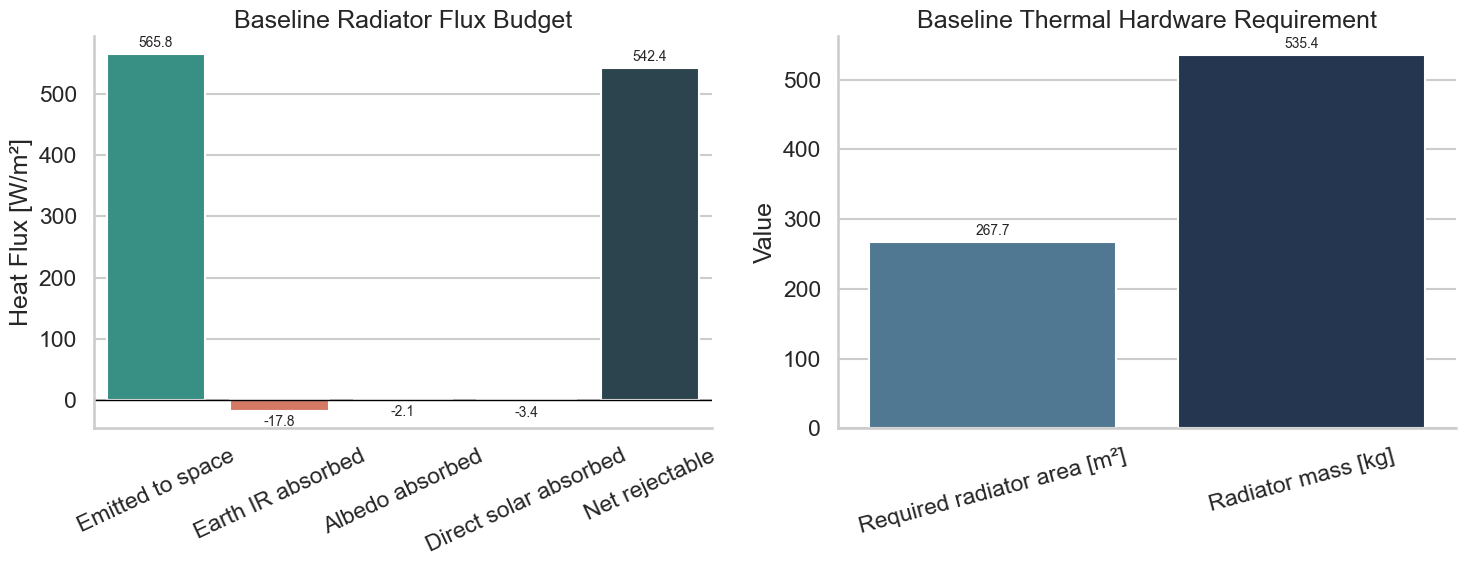

In [6]:
thermal_components = pd.DataFrame([
    {'component': 'Emitted to space', 'flux_w_m2': RAD_DIAG_BASE['q_emit_w_m2'], 'type': 'positive'},
    {'component': 'Earth IR absorbed', 'flux_w_m2': -RAD_DIAG_BASE['q_backload_earth_ir_w_m2'], 'type': 'backload'},
    {'component': 'Albedo absorbed', 'flux_w_m2': -RAD_DIAG_BASE['q_backload_albedo_w_m2'], 'type': 'backload'},
    {'component': 'Direct solar absorbed', 'flux_w_m2': -RAD_DIAG_BASE['q_backload_solar_w_m2'], 'type': 'backload'},
    {'component': 'Net rejectable', 'flux_w_m2': RAD_DIAG_BASE['q_net_w_m2'], 'type': 'net'},
])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

palette = {
    'positive': '#2a9d8f',
    'backload': '#e76f51',
    'net': '#264653',
}

sns.barplot(
    data=thermal_components,
    x='component',
    y='flux_w_m2',
    hue='type',
    dodge=False,
    palette=palette,
    ax=axes[0],
)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_ylabel('Heat Flux [W/m²]')
axes[0].set_xlabel('')
axes[0].set_title('Baseline Radiator Flux Budget')
axes[0].tick_params(axis='x', rotation=25)
axes[0].legend([], [], frameon=False)

area_mass_df = pd.DataFrame([
    {'metric': 'Required radiator area [m²]', 'value': A_RAD_M2},
    {'metric': 'Radiator mass [kg]', 'value': M_RAD_KG},
])
sns.barplot(data=area_mass_df, x='metric', y='value', palette=['#457b9d', '#1d3557'], ax=axes[1])
axes[1].set_xlabel('')
axes[1].set_ylabel('Value')
axes[1].set_title('Baseline Thermal Hardware Requirement')
axes[1].tick_params(axis='x', rotation=15)

for ax in axes:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f', padding=3, fontsize=10)

plt.tight_layout()
plt.show()

## 2) GPU operating temperature and radiator sizing

### Why GPU junction temperature is the key thermal knob

In a space-based server the only way to reject heat is radiation, and the Stefan–Boltzmann law tells us that radiated power per unit area scales as $T^4$.
The temperature that matters for radiator sizing is the **radiator surface temperature**, which is set by the GPU junction temperature minus a thermal-resistance drop through the heat-transport path:

$$T_{\text{rad}} = T_{\text{GPU,junction}} - \Delta T_{\text{transport}}$$

Our baseline uses $T_{\text{GPU}} = 90\,$°C (representative of modern data-center GPUs such as the NVIDIA H100/B200 family, whose maximum junction spec is ≈ 83–90 °C) and a transport drop $\Delta T = 30\,$°C, giving $T_{\text{rad}} = 60\,$°C.

**What is realistic?**

| GPU Temp (°C) | Radiator Temp (°C) | Interpretation |
|:---:|:---:|:---|
| 70 – 80 | 40 – 50 | Conservative / terrestrial-like. Radiators become very large. |
| **80 – 90** | **50 – 60** | **Matches current NVIDIA data-center silicon specs. Good baseline.** |
| 90 – 105 | 60 – 75 | Pushing specs — possible with hardened or custom silicon, or accepting shorter GPU life. |
| 105 – 130 | 75 – 100 | Speculative — purpose-built space compute chips. Dramatic radiator reduction but unproven. |

Because of the $T^4$ scaling, even a modest increase in allowable GPU temperature produces outsized savings in radiator area, mass, and ultimately cost.
The plots below quantify this: first the pure thermal sensitivity, then the full satellite-level cost impact per degree.

### Radiator area and mass vs GPU temperature

We vary GPU temperature and see how radiator area/mass changes, holding power constant and `ΔT_to_radiator` fixed.


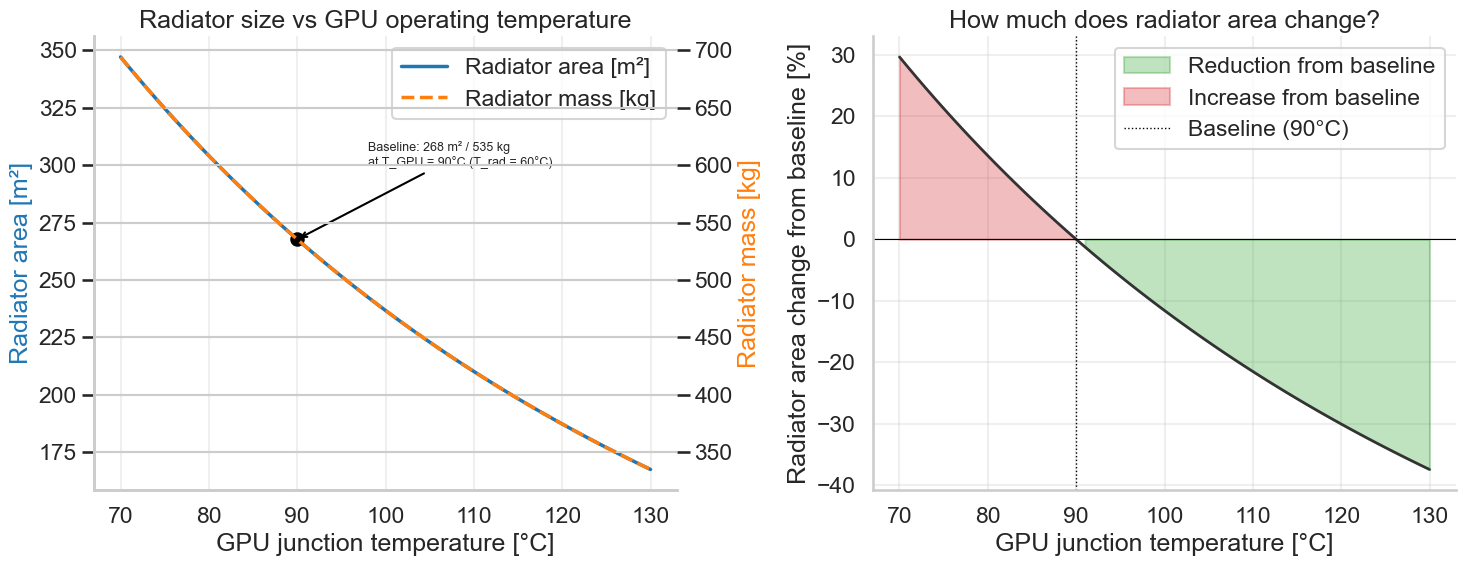

Reference points (radiator area and mass at selected GPU temperatures):
  GPU °C    Rad °C     Area m²     Mass kg   Δ vs baseline
      70        40       347.1       694.3          +29.7%
      80        50       304.1       608.2          +13.6%
      90        60       267.7       535.4           +0.0% (baseline)
     100        70       236.7       473.4          -11.6%
     110        80       210.1       420.3          -21.5%
     120        90       187.3       374.5          -30.1%
     130       100       167.5       334.9          -37.4%


In [7]:
# ---- Sweep GPU temperature for radiator sizing ----
gpu_temps = np.linspace(70, 130, 61)  # °C
rad_temps = gpu_temps - DELTA_T_TO_RADIATOR_C

areas = []
for t in rad_temps:
    a, _ = radiator_area_m2_with_backload(
        q_internal_w=P_LOAD_W,
        t_rad_c=t,
        alt_km=ALT_BASELINE_KM,
        beta_deg=BETA_DEG,
        epsilon=EPSILON,
        t_sink_k=T_SINK_K,
        k_eff=K_EFFECTIVE,
        alpha_solar=ALPHA_SOLAR,
        alpha_ir=ALPHA_IR,
        earth_ir_flux_w_m2=EARTH_IR_FLUX_W_PER_M2,
        earth_bond_albedo=EARTH_BOND_ALBEDO,
        earth_view_fraction_of_max=EARTH_VIEW_FRACTION_OF_MAX,
        radiator_solar_view_factor=RADIATOR_SOLAR_VIEW_FACTOR,
        albedo_geometry_factor=ALBEDO_GEOMETRY_FACTOR,
    )
    areas.append(a)

areas = np.array(areas)
masses = areas * RADIATOR_AREAL_DENSITY
baseline_idx = np.argmin(np.abs(gpu_temps - T_GPU_C))

# --- Figure 1: area and mass vs GPU temperature (dual axis) ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax1 = axes[0]
ax1b = ax1.twinx()
l1 = ax1.plot(gpu_temps, areas, color='#1f77b4', linewidth=2.5, label='Radiator area [m²]')
l2 = ax1b.plot(gpu_temps, masses, color='#ff7f0e', linewidth=2.5, linestyle='--', label='Radiator mass [kg]')
ax1.scatter(gpu_temps[baseline_idx], areas[baseline_idx], color='black', zorder=5, s=80)
ax1.annotate(
    f'Baseline: {areas[baseline_idx]:.0f} m² / {masses[baseline_idx]:.0f} kg\n'
    f'at T_GPU = {gpu_temps[baseline_idx]:.0f}°C (T_rad = {rad_temps[baseline_idx]:.0f}°C)',
    xy=(gpu_temps[baseline_idx], areas[baseline_idx]),
    xytext=(gpu_temps[baseline_idx] + 8, areas[baseline_idx] * 1.12),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=9,
)
ax1.set_xlabel('GPU junction temperature [°C]')
ax1.set_ylabel('Radiator area [m²]', color='#1f77b4')
ax1b.set_ylabel('Radiator mass [kg]', color='#ff7f0e')
ax1.set_title('Radiator size vs GPU operating temperature')
lines = l1 + l2
ax1.legend(lines, [l.get_label() for l in lines], loc='upper right')
ax1.grid(True, alpha=0.3)

# --- Figure 2: % reduction from baseline ---
baseline_area = areas[baseline_idx]
pct_change = 100.0 * (areas - baseline_area) / baseline_area

ax2 = axes[1]
ax2.fill_between(gpu_temps, pct_change, 0, where=(pct_change < 0),
                 color='#2ca02c', alpha=0.3, label='Reduction from baseline')
ax2.fill_between(gpu_temps, pct_change, 0, where=(pct_change >= 0),
                 color='#d62728', alpha=0.3, label='Increase from baseline')
ax2.plot(gpu_temps, pct_change, color='#333333', linewidth=2)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.axvline(T_GPU_C, color='black', linewidth=1, linestyle=':', label=f'Baseline ({T_GPU_C:.0f}°C)')
ax2.set_xlabel('GPU junction temperature [°C]')
ax2.set_ylabel('Radiator area change from baseline [%]')
ax2.set_title('How much does radiator area change?')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print a few reference points
print('Reference points (radiator area and mass at selected GPU temperatures):')
print(f'{"GPU °C":>8s}  {"Rad °C":>8s}  {"Area m²":>10s}  {"Mass kg":>10s}  {"Δ vs baseline":>14s}')
for t_gpu in [70, 80, 90, 100, 110, 120, 130]:
    idx = np.argmin(np.abs(gpu_temps - t_gpu))
    delta = 100.0 * (areas[idx] - baseline_area) / baseline_area
    tag = ' (baseline)' if abs(gpu_temps[idx] - T_GPU_C) < 0.5 else ''
    print(f'{gpu_temps[idx]:8.0f}  {rad_temps[idx]:8.0f}  {areas[idx]:10.1f}  {masses[idx]:10.1f}  {delta:+13.1f}%{tag}')


### Satellite cost savings per degree of GPU temperature

The radiator is not just mass — it propagates into launch cost, structural mass fraction, and radiator hardware cost.
Below we compute the **full satellite CAPEX** at each GPU temperature (holding everything else constant at the baseline orbit) and plot:

1. Total satellite cost vs GPU temperature.
2. **Marginal cost savings per additional degree** — i.e., how much cheaper the satellite gets for each +1°C of allowable GPU temperature.

This directly answers: *"Is it worth investing in thermal design to allow hotter GPU operation?"*


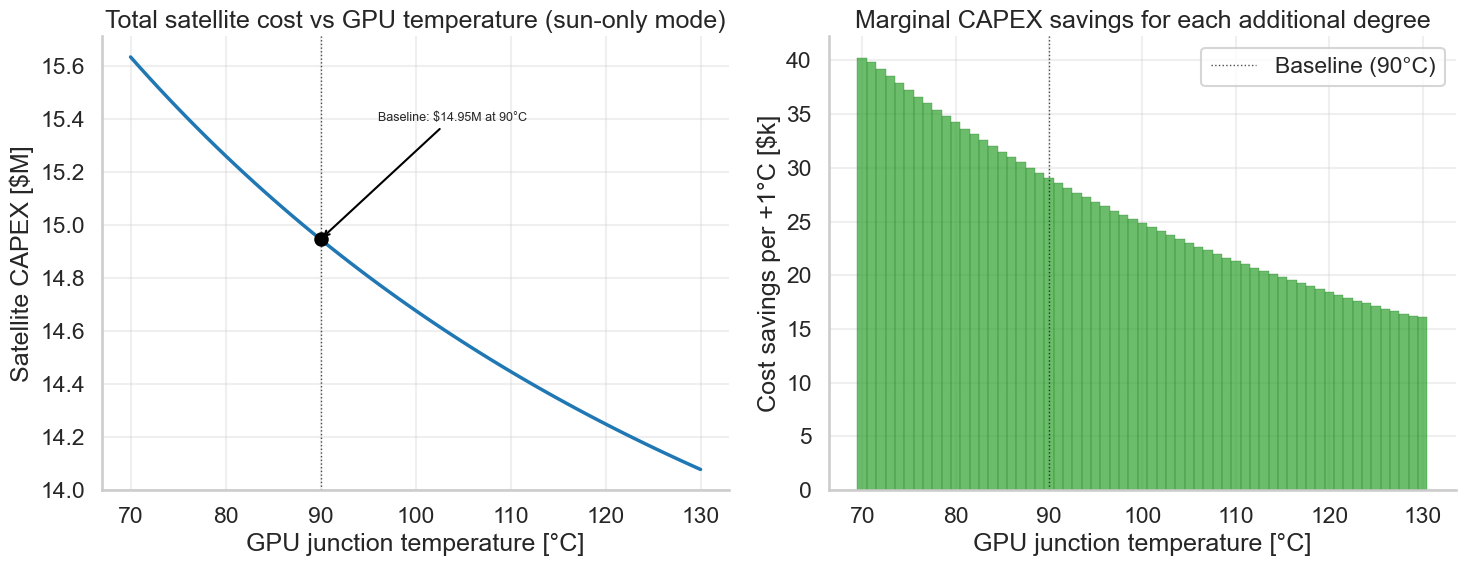


Satellite cost at selected GPU temperatures (sun-only, baseline orbit):
  GPU °C    Rad °C    Rad m²    Total kg    CAPEX $M   Δ vs baseline   Savings/°C $k
      70        40     347.1      2027.0      15.634           +4.6%            40.2
      80        50     304.1      1912.3      15.261           +2.1%            34.2
      85        55     285.2      1861.8      15.097           +1.0%            31.5
      90        60     267.7      1815.2      14.945           +0.0%            29.1 *
      95        65     251.6      1772.2      14.806           -0.9%            26.8
     100        70     236.7      1732.5      14.677           -1.8%            24.8
     110        80     210.1      1661.7      14.446           -3.3%            21.3
     120        90     187.3      1600.7      14.248           -4.7%            18.4
     130       100     167.5      1547.9      14.077           -5.8%            16.1


In [8]:
# ---- Full satellite cost vs GPU temperature ----
def satellite_cost_at_gpu_temp(t_gpu_c: float) -> dict:
    """Compute full satellite mass breakdown and CAPEX for a given GPU junction temp."""
    t_rad_c = t_gpu_c - DELTA_T_TO_RADIATOR_C
    beta = BETA_DEG
    f = sunlight_fraction(ALT_BASELINE_KM, beta)

    a_rad, rad_diag = radiator_area_m2_with_backload(
        q_internal_w=P_LOAD_W,
        t_rad_c=t_rad_c,
        alt_km=ALT_BASELINE_KM,
        beta_deg=beta,
        epsilon=EPSILON,
        t_sink_k=T_SINK_K,
        k_eff=K_EFFECTIVE,
        alpha_solar=ALPHA_SOLAR,
        alpha_ir=ALPHA_IR,
        earth_ir_flux_w_m2=EARTH_IR_FLUX_W_PER_M2,
        earth_bond_albedo=EARTH_BOND_ALBEDO,
        earth_view_fraction_of_max=EARTH_VIEW_FRACTION_OF_MAX,
        radiator_solar_view_factor=RADIATOR_SOLAR_VIEW_FACTOR,
        albedo_geometry_factor=ALBEDO_GEOMETRY_FACTOR,
    )
    m_rad = a_rad * RADIATOR_AREAL_DENSITY

    # Sun-only mode for simplicity (isolates thermal effect)
    p_array = P_LOAD_W
    m_array = p_array / ARRAY_SPECIFIC_POWER_W_PER_KG

    m_nonbus = M_COMPUTE_KG + m_rad + m_array
    m_total = total_mass_with_bus(m_nonbus, BUS_MASS_FRACTION_OF_TOTAL)

    compute_cost = COMPUTE_COST_PER_KW * P_COMPUTE_KW
    array_cost = p_array * ARRAY_COST_PER_W
    rad_cost = a_rad * RADIATOR_COST_PER_M2
    cost_per_kg = effective_cost_per_kg_to_altitude(
        ALT_BASELINE_KM, ALT_BASELINE_KM, COST_TO_BASELINE_PER_KG,
        ISP_TRANSFER_S, PROPULSION_STRUCT_FRAC,
    )
    launch_cost = m_total * cost_per_kg
    capex = compute_cost + array_cost + rad_cost + BUS_COST_FIXED + launch_cost

    return {
        't_gpu_c': t_gpu_c,
        't_rad_c': t_rad_c,
        'a_rad_m2': a_rad,
        'm_rad_kg': m_rad,
        'm_total_kg': m_total,
        'capex_usd': capex,
        'launch_cost_usd': launch_cost,
        'rad_cost_usd': rad_cost,
    }

# Fine-grained sweep (1°C steps)
gpu_temps_fine = np.arange(70, 131, 1.0)
cost_rows = [satellite_cost_at_gpu_temp(t) for t in gpu_temps_fine]
cost_df = pd.DataFrame(cost_rows)

# Marginal savings: Δcost for each +1°C
cost_df['marginal_savings_usd_per_deg'] = -np.gradient(cost_df['capex_usd'], cost_df['t_gpu_c'])

baseline_cost = cost_df.loc[cost_df['t_gpu_c'] == T_GPU_C, 'capex_usd'].values[0]

# ---- Figure: two subplots ----
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: total satellite cost
ax1 = axes[0]
ax1.plot(cost_df['t_gpu_c'], cost_df['capex_usd'] / 1e6, color='#1f77b4', linewidth=2.5)
ax1.axvline(T_GPU_C, color='black', linewidth=1, linestyle=':', alpha=0.7)
ax1.scatter([T_GPU_C], [baseline_cost / 1e6], color='black', zorder=5, s=80)
ax1.annotate(
    f'Baseline: ${baseline_cost/1e6:.2f}M at {T_GPU_C:.0f}°C',
    xy=(T_GPU_C, baseline_cost / 1e6),
    xytext=(T_GPU_C + 6, baseline_cost / 1e6 * 1.03),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=9,
)
ax1.set_xlabel('GPU junction temperature [°C]')
ax1.set_ylabel('Satellite CAPEX [$M]')
ax1.set_title('Total satellite cost vs GPU temperature (sun-only mode)')
ax1.grid(True, alpha=0.3)

# Right: marginal savings per degree
ax2 = axes[1]
ax2.bar(cost_df['t_gpu_c'], cost_df['marginal_savings_usd_per_deg'] / 1e3,
        width=1.0, color='#2ca02c', alpha=0.7, edgecolor='#1a7a1a', linewidth=0.3)
ax2.axvline(T_GPU_C, color='black', linewidth=1, linestyle=':', alpha=0.7,
            label=f'Baseline ({T_GPU_C:.0f}°C)')
ax2.set_xlabel('GPU junction temperature [°C]')
ax2.set_ylabel('Cost savings per +1°C [$k]')
ax2.set_title('Marginal CAPEX savings for each additional degree')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary table
print('\nSatellite cost at selected GPU temperatures (sun-only, baseline orbit):')
print(f'{"GPU °C":>8s}  {"Rad °C":>8s}  {"Rad m²":>8s}  {"Total kg":>10s}  '
      f'{"CAPEX $M":>10s}  {"Δ vs baseline":>14s}  {"Savings/°C $k":>14s}')
for t_gpu in [70, 80, 85, 90, 95, 100, 110, 120, 130]:
    row = cost_df.loc[cost_df['t_gpu_c'] == t_gpu].iloc[0]
    delta_pct = 100.0 * (row['capex_usd'] - baseline_cost) / baseline_cost
    tag = ' *' if abs(t_gpu - T_GPU_C) < 0.5 else ''
    print(f'{row["t_gpu_c"]:8.0f}  {row["t_rad_c"]:8.0f}  {row["a_rad_m2"]:8.1f}  '
          f'{row["m_total_kg"]:10.1f}  {row["capex_usd"]/1e6:10.3f}  '
          f'{delta_pct:+13.1f}%  {row["marginal_savings_usd_per_deg"]/1e3:14.1f}{tag}')


## 3) Sunlight availability vs altitude and orbital geometry

The thermal analysis above tells us *how much radiator we need per watt*. But the question of *how many watts we can actually generate* depends on how often our satellites see the Sun. In space, solar arrays are the only practical power source at this scale, and they only work when sunlit. Every minute a satellite spends in Earth's shadow is a minute with no power generation — and for a datacenter that needs to run inference, that is either downtime or battery mass.

Two geometric factors dominate sunlight availability:

### Altitude: higher orbits see shorter eclipses

A satellite in a circular orbit traces a great circle around the Earth at a fixed altitude. Each orbit, it passes through Earth's shadow cone — an "eclipse." The key insight is geometric: as altitude increases, the orbit gets larger but Earth stays the same size. The shadow subtends a smaller fraction of the orbit, so eclipses get shorter relative to the orbital period.

At LEO altitudes (400–600 km), a worst-case eclipse can last ~36 minutes out of a ~95-minute orbit — roughly 38% of each orbit in darkness. By 2,000 km, the shadow fraction drops noticeably. Above ~10,000 km, eclipses become quite short relative to the much longer orbital period.

### Beta angle ($\beta$): the orbit-plane geometry relative to the Sun

The **beta angle** is the angle between the Sun's direction and the satellite's orbital plane. It is the single most important geometric parameter for sunlight availability:

- **$\beta = 0°$ (Sun in the orbital plane)**: the satellite flies directly into and out of Earth's shadow every orbit. This is the *worst-case eclipse season* — maximum shadow time.
- **$\beta = 90°$ (Sun perpendicular to the orbital plane)**: the orbit is "edge-on" to the Sun. The satellite can fly over the sunlit face of the Earth continuously, never entering the shadow. This is the **dawn-dusk** geometry — permanent sunlight.
- **Intermediate $\beta$ values**: the eclipse gets progressively shorter as $\beta$ increases, until a critical angle (which depends on altitude) where eclipses vanish entirely.

For any given altitude, there is a threshold beta angle above which the satellite is in permanent sunlight. This threshold is lower at higher altitudes (because the shadow cone is relatively smaller).

### Sunlight fraction ($f_{sun}$)

We define **sunlight fraction** as the fraction of each orbit spent in sunlight. Using a simple **cylindrical Earth-shadow model** (which treats the shadow as a cylinder rather than a cone — a good first-order approximation), we compute $f_{sun}$ as a function of altitude and $\beta$.

- $f_{sun} = 1.0$ means continuous sunlight (no eclipse).
- Lower $f_{sun}$ means longer eclipses and either:
  - more downtime (sunlight-only operation), or
  - larger batteries and oversized solar arrays (for 24/7 operation).

Below, we visualize $f_{sun}$ in two ways:
1. A **heatmap** over altitude and beta angle — showing the full landscape of sunlight geometry.
2. A **slice at the baseline beta** ($\beta = 0°$, worst case) — showing how altitude alone improves eclipse duration.

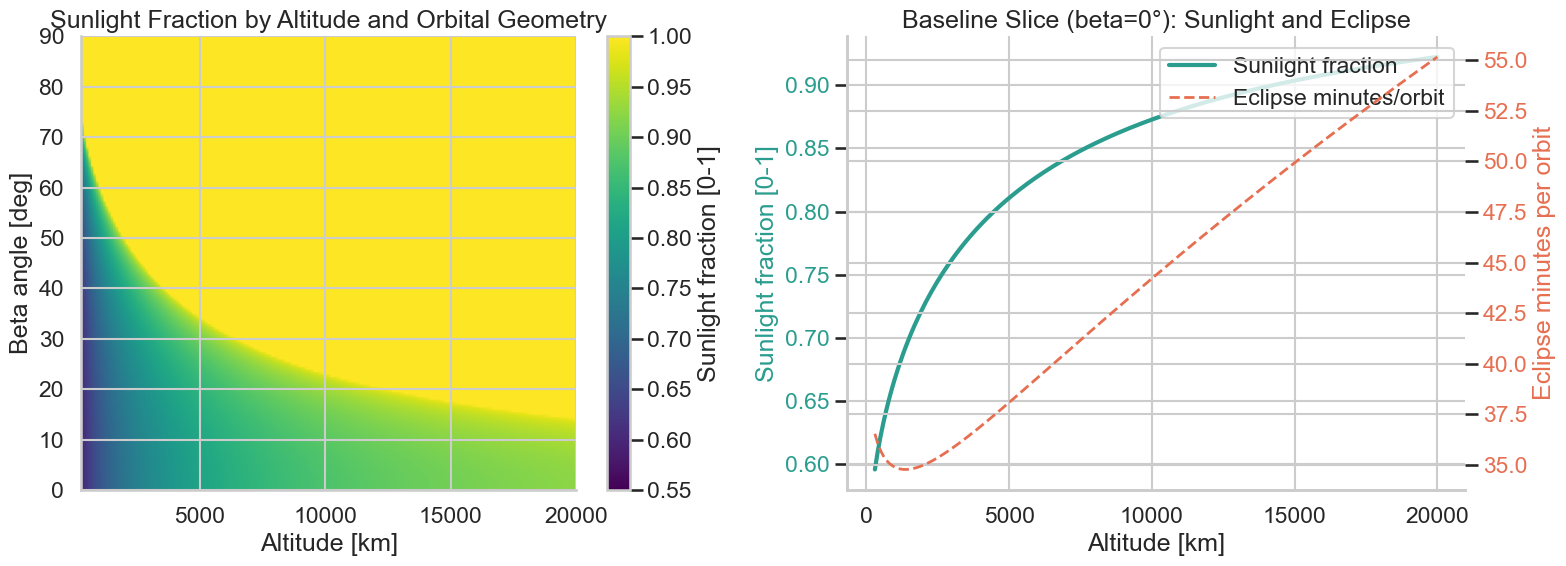

In [9]:
alts = np.linspace(300, 20_000, 200)  # km
betas = np.linspace(0, 90, 181)      # deg

sun_grid = np.array([[sunlight_fraction(a, b) for a in alts] for b in betas])

# Baseline-beta slice
f_sun = np.array([sunlight_fraction(a, BETA_DEG) for a in alts])
period = np.array([orbital_period_s(a) for a in alts])
eclipse_min = (1 - f_sun) * period / 60.0

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

hm = axes[0].imshow(
    sun_grid,
    aspect='auto',
    origin='lower',
    extent=[alts.min(), alts.max(), betas.min(), betas.max()],
    cmap='viridis',
    vmin=0.55,
    vmax=1.0,
)
axes[0].set_xlabel('Altitude [km]')
axes[0].set_ylabel('Beta angle [deg]')
axes[0].set_title('Sunlight Fraction by Altitude and Orbital Geometry')
cbar = plt.colorbar(hm, ax=axes[0])
cbar.set_label('Sunlight fraction [0-1]')

axes[1].plot(alts, f_sun, color='#2a9d8f', linewidth=3, label='Sunlight fraction')
axes[1].set_xlabel('Altitude [km]')
axes[1].set_ylabel('Sunlight fraction [0-1]', color='#2a9d8f')
axes[1].tick_params(axis='y', labelcolor='#2a9d8f')
axes[1].set_title(f'Baseline Slice (beta={BETA_DEG:.0f}°): Sunlight and Eclipse')

ax2 = axes[1].twinx()
ax2.plot(alts, eclipse_min, color='#e76f51', linewidth=2, linestyle='--', label='Eclipse minutes/orbit')
ax2.set_ylabel('Eclipse minutes per orbit', color='#e76f51')
ax2.tick_params(axis='y', labelcolor='#e76f51')

handles1, labels1 = axes[1].get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(handles1 + handles2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

## 4) Internet-service sunlight scenarios and constellation view

### Why a single satellite's geometry doesn't tell the whole story

If we were designing a single experimental satellite, we could pick the most favorable orbit — a dawn-dusk sun-synchronous orbit at high beta angle, giving near-continuous sunlight. But an LLM inference constellation is not a single satellite. It needs to serve users across different geographic regions and local times, which forces a spread of orbital planes.

### What drives constellation geometry

A satellite's ground coverage footprint is determined by its altitude — higher orbits see more of the Earth's surface at once. But to provide continuous, low-latency service to users across the globe, a constellation distributes satellites across many **orbital planes**. Each plane has a different orientation defined by its **RAAN** (Right Ascension of the Ascending Node — essentially, which direction the orbital plane faces in space).

Because the Sun illuminates Earth from a fixed direction at any given time, different orbital planes naturally have different **beta angles**:
- Planes aligned near the dawn-dusk terminator enjoy high $\beta$ and near-continuous sunlight.
- Planes oriented perpendicular to this (flying "into" and "away from" the Sun) have low $\beta$ and experience full eclipses.

A constellation designed for global coverage cannot avoid low-beta planes — it needs them for geographic coverage. The result is a **mix of beta angles across the fleet**, which is what we model here.

### The constellation beta mix

Rather than modeling every individual orbital plane, we use a simplified **weighted beta mix**: a set of representative beta angles and the fraction of the fleet operating near each one. Our default mix (`CONSTELLATION_BETA_MIX`) is:

| Beta bin | Weight | Interpretation |
|----------|--------|---------------|
| 0° | 30% | Worst-case eclipse season planes |
| 30° | 45% | Moderate geometry (most planes) |
| 60° | 20% | High-beta, favorable planes |
| 90° | 5% | Ideal dawn-dusk (rare in coverage-optimized designs) |

This mix reflects a practical reality: most planes in a large coverage constellation will sit at moderate beta angles, with only a small fraction achieving ideal dawn-dusk conditions.

### What we compute below

For each beta scenario and the weighted constellation mix, we show:
1. **Sunlight fraction vs. altitude** — how much each geometry benefits from going higher.
2. **Array oversize factor for 24/7 operation** ($1/f_{sun}$) — how much extra solar array capacity is needed to charge batteries during sunlight to cover eclipse periods.
3. **Communications tradeoffs** — a compact table of ground footprint radius and one-way propagation delay at representative altitudes, to anchor the altitude choice in real service constraints.

The key question for service design: *how much power-system oversizing and cost is needed to maintain consistent delivered compute across a realistic constellation?*

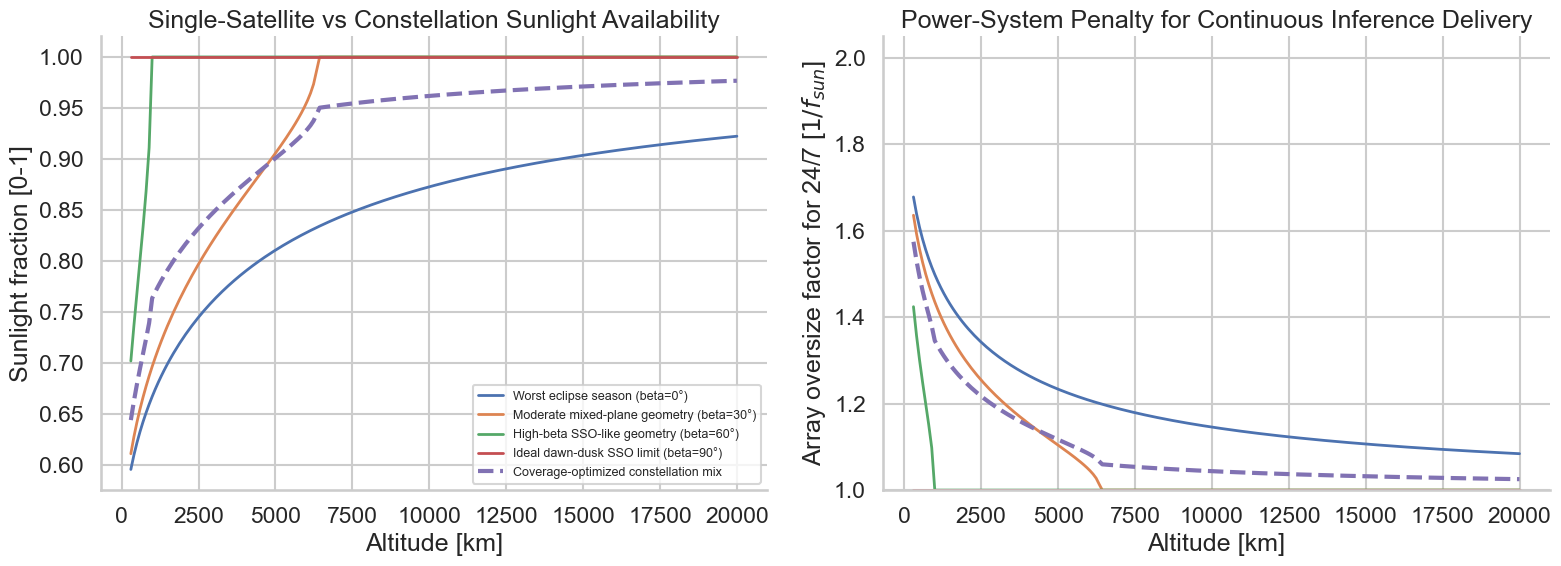

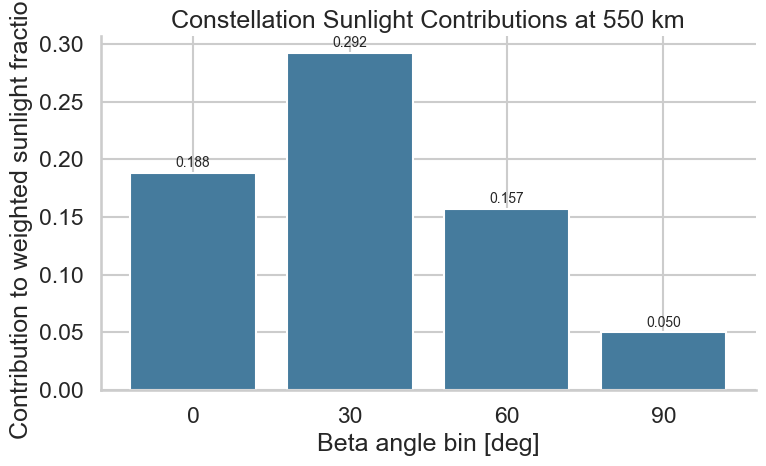

,alt_km,max_ground_footprint_radius_km,one_way_nadir_propagation_ms
0,550,2557.045290,1.834603
1,700,2858.780716,2.334949
2,1000,3357.347100,3.335641
3,2000,4496.779115,6.671282
4,10000,7460.904211,33.356410


In [10]:
# Scenario set to represent different operational constellation geometries.
SUNLIGHT_SCENARIOS = [
    ('Worst eclipse season (beta=0°)', 0.0),
    ('Moderate mixed-plane geometry (beta=30°)', 30.0),
    ('High-beta SSO-like geometry (beta=60°)', 60.0),
    ('Ideal dawn-dusk SSO limit (beta=90°)', 90.0),
]

# Coverage-oriented constellation mix across planes (from model knobs).
CONSTELLATION_MIX = normalize_beta_mix(CONSTELLATION_BETA_MIX)

scenario_rows = []
for alt in alts:
    t_orbit_s = orbital_period_s(alt)

    for scenario_name, beta in SUNLIGHT_SCENARIOS:
        f = sunlight_fraction(alt, beta)
        eclipse_min = (1.0 - f) * t_orbit_s / 60.0
        array_oversize_247 = 1.0 / max(f, 1e-6)
        scenario_rows.append({
            'scenario': scenario_name,
            'beta_deg': beta,
            'alt_km': alt,
            'sunlight_fraction': f,
            'eclipse_min': eclipse_min,
            'array_oversize_247': array_oversize_247,
        })

    mix_metrics = constellation_sunlight_metrics(alt, CONSTELLATION_MIX)
    scenario_rows.append({
        'scenario': 'Coverage-optimized constellation mix',
        'beta_deg': np.nan,
        'alt_km': alt,
        'sunlight_fraction': mix_metrics['sunlight_fraction_weighted'],
        'eclipse_min': mix_metrics['eclipse_min_weighted'],
        'array_oversize_247': mix_metrics['array_oversize_247_weighted'],
    })

sun_df = pd.DataFrame(scenario_rows)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for name in sun_df['scenario'].unique():
    s = sun_df[sun_df['scenario'] == name]
    style = '--' if name == 'Coverage-optimized constellation mix' else '-'
    width = 3 if name == 'Coverage-optimized constellation mix' else 2
    axes[0].plot(s['alt_km'], s['sunlight_fraction'], linestyle=style, linewidth=width, label=name)

axes[0].set_xlabel('Altitude [km]')
axes[0].set_ylabel('Sunlight fraction [0-1]')
axes[0].set_title('Single-Satellite vs Constellation Sunlight Availability')
axes[0].legend(fontsize=9)

for name in sun_df['scenario'].unique():
    s = sun_df[sun_df['scenario'] == name]
    style = '--' if name == 'Coverage-optimized constellation mix' else '-'
    width = 3 if name == 'Coverage-optimized constellation mix' else 2
    axes[1].plot(s['alt_km'], s['array_oversize_247'], linestyle=style, linewidth=width, label=name)

axes[1].set_xlabel('Altitude [km]')
axes[1].set_ylabel('Array oversize factor for 24/7 [$1/f_{sun}$]')
axes[1].set_title('Power-System Penalty for Continuous Inference Delivery')
axes[1].set_ylim(1.0, 2.05)

plt.tight_layout()
plt.show()

# Show a compact table at representative altitudes for blog readability.
mix_table_rows = []
for alt in [550, 700, 1000, 2000]:
    m = constellation_sunlight_metrics(alt, CONSTELLATION_MIX)
    mix_table_rows.append({
        'alt_km': alt,
        'weighted_sunlight_fraction': m['sunlight_fraction_weighted'],
        'weighted_eclipse_min': m['eclipse_min_weighted'],
        'weighted_array_oversize_247': m['array_oversize_247_weighted'],
    })
mix_table = pd.DataFrame(mix_table_rows)
mix_table

# Beta-mix contribution chart at baseline altitude.
mix_contrib_rows = []
for beta, w in CONSTELLATION_MIX:
    f = sunlight_fraction(ALT_BASELINE_KM, beta)
    mix_contrib_rows.append({
        'beta_deg': beta,
        'mix_weight': w,
        'sunlight_fraction': f,
        'weighted_contribution': w * f,
    })

mix_contrib = pd.DataFrame(mix_contrib_rows)
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(mix_contrib['beta_deg'].astype(int).astype(str), mix_contrib['weighted_contribution'], color='#457b9d')
ax.set_xlabel('Beta angle bin [deg]')
ax.set_ylabel('Contribution to weighted sunlight fraction')
ax.set_title(f'Constellation Sunlight Contributions at {ALT_BASELINE_KM:.0f} km')
for i, v in enumerate(mix_contrib['weighted_contribution']):
    ax.text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

# Simple communications tradeoff proxies for Earth internet service.
C_LIGHT_M_PER_S = 299_792_458.0
comm_rows = []
for alt in [550, 700, 1000, 2000, 10_000]:
    r = R_EARTH + 1_000.0 * alt
    horizon_half_angle_rad = np.arccos(R_EARTH / r)
    ground_footprint_radius_km = (R_EARTH * horizon_half_angle_rad) / 1000.0
    one_way_nadir_ms = (1_000.0 * alt / C_LIGHT_M_PER_S) * 1_000.0
    comm_rows.append({
        'alt_km': alt,
        'max_ground_footprint_radius_km': ground_footprint_radius_km,
        'one_way_nadir_propagation_ms': one_way_nadir_ms,
    })

pd.DataFrame(comm_rows)

## 5) Mass and cost vs altitude

We compute mass + cost for each altitude under two operating modes:
- **Sunlight-only inference** (no batteries): cheaper & lighter, but only runs during sunlight.
- **24/7** (arrays + batteries): runs continuously, but adds battery mass and larger arrays.

We also compute a simple “effective $/kg to target altitude” based on a baseline cost to a baseline orbit plus a Hohmann transfer.


In [11]:
def satellite_mass_breakdown(alt_km: float, mode: str, beta_deg=None) -> dict:
    """Return mass breakdown for a single satellite at altitude for a given mode."""
    beta = BETA_DEG if beta_deg is None else float(beta_deg)
    f = sunlight_fraction(alt_km, beta)

    # Radiator mass includes orbit-dependent thermal backload.
    a_rad, rad_diag = radiator_area_m2_with_backload(
        q_internal_w=P_LOAD_W,
        t_rad_c=T_RAD_C,
        alt_km=alt_km,
        beta_deg=beta,
        epsilon=EPSILON,
        t_sink_k=T_SINK_K,
        k_eff=K_EFFECTIVE,
        alpha_solar=ALPHA_SOLAR,
        alpha_ir=ALPHA_IR,
        earth_ir_flux_w_m2=EARTH_IR_FLUX_W_PER_M2,
        earth_bond_albedo=EARTH_BOND_ALBEDO,
        earth_view_fraction_of_max=EARTH_VIEW_FRACTION_OF_MAX,
        radiator_solar_view_factor=RADIATOR_SOLAR_VIEW_FACTOR,
        albedo_geometry_factor=ALBEDO_GEOMETRY_FACTOR,
    )
    m_rad = a_rad * RADIATOR_AREAL_DENSITY

    if mode == "sunonly":
        p_array = P_LOAD_W
        m_array = p_array / ARRAY_SPECIFIC_POWER_W_PER_KG
        m_batt = 0.0
        uptime = f
    elif mode == "247":
        p_array = P_LOAD_W / max(f, 1e-6)
        m_array = p_array / ARRAY_SPECIFIC_POWER_W_PER_KG

        t_orbit = orbital_period_s(alt_km)
        t_eclipse = (1 - f) * t_orbit
        e_batt_wh = (P_LOAD_W/1000) * (t_eclipse/3600) / (BATTERY_ROUND_TRIP_EFF * BATTERY_DOD) * 1000
        m_batt = e_batt_wh / BATTERY_SPECIFIC_ENERGY_WH_PER_KG
        uptime = 1.0
    else:
        raise ValueError("mode must be 'sunonly' or '247'")

    m_nonbus = M_COMPUTE_KG + m_rad + m_array + m_batt
    m_total = total_mass_with_bus(m_nonbus, BUS_MASS_FRACTION_OF_TOTAL)

    avg_compute_kw = P_COMPUTE_KW * uptime

    return {
        "alt_km": alt_km,
        "mode": mode,
        "beta_deg": beta,
        "sunlight_fraction": f,
        "uptime_fraction": uptime,
        "m_compute_kg": M_COMPUTE_KG,
        "a_radiator_m2": a_rad,
        "m_radiator_kg": m_rad,
        "q_backload_w_m2": rad_diag["q_backload_total_w_m2"],
        "q_net_radiator_w_m2": rad_diag["q_net_w_m2"],
        "m_array_kg": m_array,
        "m_battery_kg": m_batt,
        "m_total_kg": m_total,
        "p_array_peak_w": p_array,
        "avg_compute_kw": avg_compute_kw,
        "specific_compute_w_per_kg": (1_000.0 * P_COMPUTE_KW) / m_total,
        "specific_load_w_per_kg": P_LOAD_W / m_total,
    }

def satellite_capex_usd(breakdown: dict) -> float:
    """Very simplified CAPEX: compute ($/kW coupled) + arrays + radiators + batteries + bus + launch."""
    compute_cost = COMPUTE_COST_PER_KW * P_COMPUTE_KW

    array_cost = breakdown["p_array_peak_w"] * ARRAY_COST_PER_W
    rad_cost = breakdown["a_radiator_m2"] * RADIATOR_COST_PER_M2
    batt_cost = (breakdown["m_battery_kg"] * BATTERY_SPECIFIC_ENERGY_WH_PER_KG / 1000) * BATTERY_COST_PER_KWH  # kWh

    cost_per_kg = effective_cost_per_kg_to_altitude(
        breakdown["alt_km"], ALT_BASELINE_KM, COST_TO_BASELINE_PER_KG,
        ISP_TRANSFER_S, PROPULSION_STRUCT_FRAC,
    )
    launch_cost = breakdown["m_total_kg"] * cost_per_kg

    return float(compute_cost + array_cost + rad_cost + batt_cost + BUS_COST_FIXED + launch_cost)

rows = []
for a in alts:
    for mode in ["sunonly", "247"]:
        b = satellite_mass_breakdown(a, mode)
        capex = satellite_capex_usd(b)
        b["capex_usd"] = capex
        b["capex_per_avg_compute_kw_usd_per_kw"] = capex / max(b["avg_compute_kw"], 1e-9)
        rows.append(b)

df = pd.DataFrame(rows)
df.head()


,alt_km,mode,beta_deg,sunlight_fraction,uptime_fraction,m_compute_kg,a_radiator_m2,m_radiator_kg,q_backload_w_m2,q_net_radiator_w_m2,m_array_kg,m_battery_kg,m_total_kg,p_array_peak_w,avg_compute_kw,specific_compute_w_per_kg,specific_load_w_per_kg,capex_usd,capex_per_avg_compute_kw_usd_per_kw
0,300.000000,sunonly,0.0,0.595823,0.595823,100.0,268.310325,536.620649,24.626569,541.164415,726.000000,0.00000,1816.827532,145200.000000,78.648684,72.654117,79.919529,1.495069e+07,190094.591496
1,300.000000,247,0.0,0.595823,1.000000,100.0,268.310325,536.620649,24.626569,541.164415,1218.481925,613.86125,3291.951765,243696.384918,132.000000,40.097793,44.107572,2.358787e+07,178696.013316
2,398.994975,sunonly,0.0,0.609827,0.609827,100.0,268.065170,536.130341,24.131657,541.659328,726.000000,0.00000,1816.173788,145200.000000,80.497228,72.680269,79.948296,1.494856e+07,185702.850966
3,398.994975,247,0.0,0.609827,1.000000,100.0,268.065170,536.130341,24.131657,541.659328,1190.500616,605.83142,3243.283169,238100.123174,132.000000,40.699499,44.769449,2.318558e+07,175648.315752
4,497.989950,sunonly,0.0,0.621952,0.621952,100.0,267.823972,535.647944,23.643846,542.147138,726.000000,0.00000,1815.530592,145200.000000,82.097643,72.706018,79.976620,1.494647e+07,182057.290218


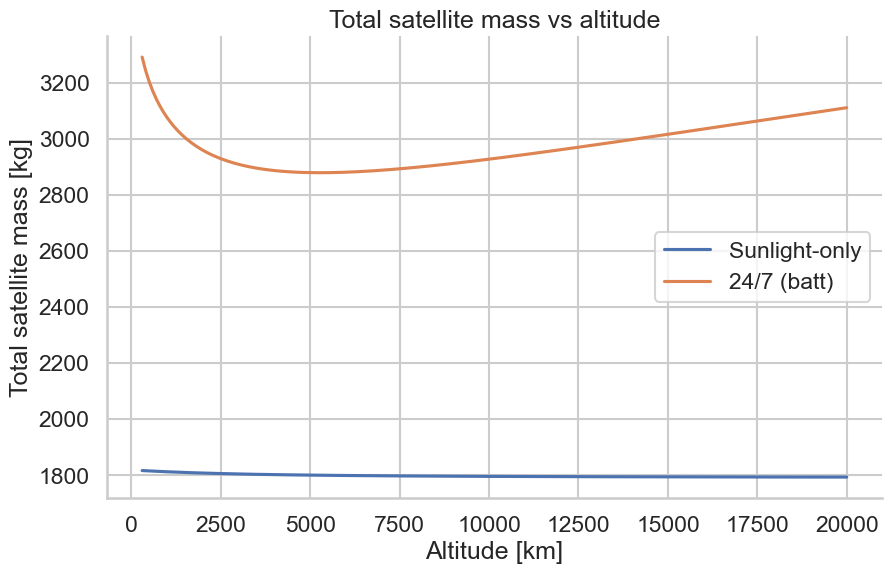

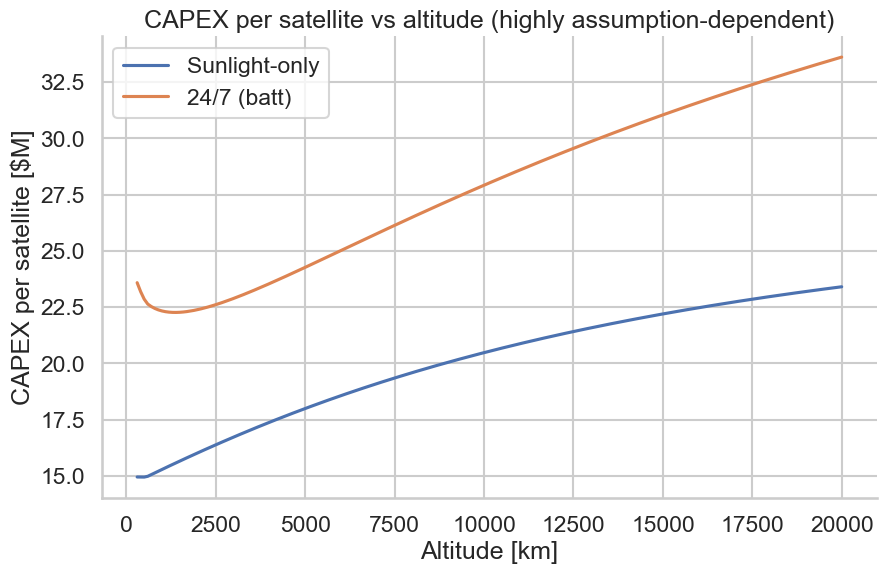

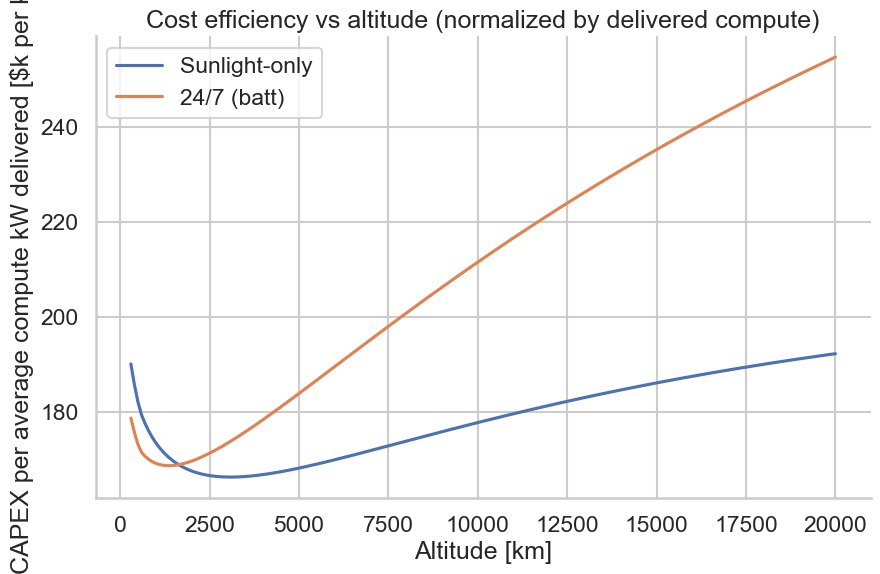

In [12]:
# Plot: Total mass vs altitude
plt.figure()
for mode, label in [("sunonly", "Sunlight-only"), ("247", "24/7 (batt)") ]:
    sub = df[df["mode"] == mode]
    plt.plot(sub["alt_km"], sub["m_total_kg"], label=label)
plt.xlabel("Altitude [km]")
plt.ylabel("Total satellite mass [kg]")
plt.title("Total satellite mass vs altitude")
plt.grid(True)
plt.legend()
plt.show()

# Plot: CAPEX per satellite vs altitude
plt.figure()
for mode, label in [("sunonly", "Sunlight-only"), ("247", "24/7 (batt)") ]:
    sub = df[df["mode"] == mode]
    plt.plot(sub["alt_km"], sub["capex_usd"]/1e6, label=label)
plt.xlabel("Altitude [km]")
plt.ylabel("CAPEX per satellite [$M]")
plt.title("CAPEX per satellite vs altitude (highly assumption-dependent)")
plt.grid(True)
plt.legend()
plt.show()

# Plot: CAPEX per *average delivered compute* kW
plt.figure()
for mode, label in [("sunonly", "Sunlight-only"), ("247", "24/7 (batt)") ]:
    sub = df[df["mode"] == mode]
    plt.plot(sub["alt_km"], sub["capex_per_avg_compute_kw_usd_per_kw"]/1e3, label=label)
plt.xlabel("Altitude [km]")
plt.ylabel("CAPEX per average compute kW delivered [$k per kW]")
plt.title("Cost efficiency vs altitude (normalized by delivered compute)")
plt.grid(True)
plt.legend()
plt.show()


### Cost-per-additional-km (marginal)

We compute a simple numerical derivative of total CAPEX with respect to altitude. This is **not** a market price curve — it's a visualization of what the model implies under our assumptions.


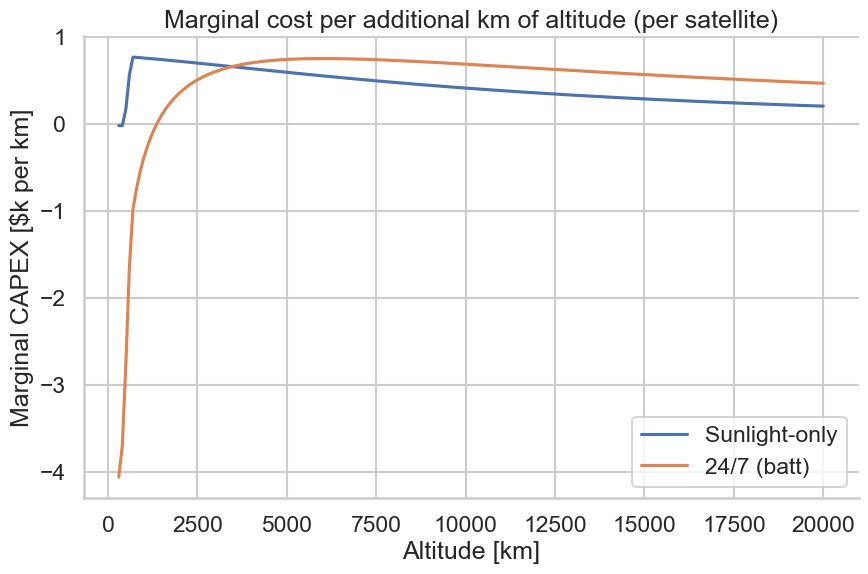

In [13]:
def marginal_cost_per_km(sub: pd.DataFrame) -> pd.DataFrame:
    s = sub.sort_values("alt_km").copy()
    s["capex_d_usd_per_km"] = np.gradient(s["capex_usd"], s["alt_km"])
    return s

plt.figure()
for mode, label in [("sunonly", "Sunlight-only"), ("247", "24/7 (batt)") ]:
    sub = marginal_cost_per_km(df[df["mode"] == mode])
    plt.plot(sub["alt_km"], sub["capex_d_usd_per_km"]/1e3, label=label)
plt.xlabel("Altitude [km]")
plt.ylabel("Marginal CAPEX [$k per km]")
plt.title("Marginal cost per additional km of altitude (per satellite)")
plt.grid(True)
plt.legend()
plt.show()


## 6) Constellation scaling (optional)

If you want a fleet with **TARGET_TOTAL_COMPUTE_MW**, we estimate satellite count and fleet cost.

This section now includes two variants:
- **single-beta fleet**: all satellites assumed to operate at one beta angle (`BETA_DEG`)
- **coverage-optimized beta mix**: satellites distributed across `CONSTELLATION_BETA_MIX`

The mix is intended as a realistic simplification for global internet LLM serving, where planes are spread for coverage and not all can remain at dawn-dusk geometry.


In [14]:
def fleet_estimate(alt_km: float, mode: str, target_compute_mw: float, beta_deg=None) -> dict:
    beta = BETA_DEG if beta_deg is None else float(beta_deg)
    b = satellite_mass_breakdown(alt_km, mode, beta_deg=beta)
    sat_avg_mw = b["avg_compute_kw"] / 1000
    n_sats = int(np.ceil(target_compute_mw / max(sat_avg_mw, 1e-9)))
    capex = satellite_capex_usd(b) * n_sats
    return {
        "alt_km": alt_km,
        "mode": mode,
        "beta_deg": beta,
        "target_compute_mw": target_compute_mw,
        "satellites_needed": n_sats,
        "fleet_capex_usd": capex,
        "fleet_mass_tonnes": n_sats * b["m_total_kg"] / 1000,
        "avg_compute_mw_delivered": n_sats * sat_avg_mw,
        "sunlight_fraction": b["sunlight_fraction"],
    }

def fleet_estimate_constellation_mix(alt_km: float, mode: str, target_compute_mw: float, beta_mix: list) -> dict:
    mix = normalize_beta_mix(beta_mix)

    per_beta_rows = []
    for beta, w in mix:
        b = satellite_mass_breakdown(alt_km, mode, beta_deg=beta)
        per_beta_rows.append({
            "beta_deg": beta,
            "weight": w,
            "sunlight_fraction": b["sunlight_fraction"],
            "avg_compute_kw": b["avg_compute_kw"],
            "m_total_kg": b["m_total_kg"],
            "sat_capex_usd": satellite_capex_usd(b),
        })

    mix_df = pd.DataFrame(per_beta_rows)
    sat_avg_mw_weighted = float(np.sum(mix_df["weight"] * mix_df["avg_compute_kw"]) / 1000.0)
    sat_mass_kg_weighted = float(np.sum(mix_df["weight"] * mix_df["m_total_kg"]))
    sat_capex_usd_weighted = float(np.sum(mix_df["weight"] * mix_df["sat_capex_usd"]))
    sunlight_fraction_weighted = float(np.sum(mix_df["weight"] * mix_df["sunlight_fraction"]))

    n_sats = int(np.ceil(target_compute_mw / max(sat_avg_mw_weighted, 1e-9)))

    return {
        "alt_km": alt_km,
        "mode": mode,
        "target_compute_mw": target_compute_mw,
        "satellites_needed": n_sats,
        "fleet_capex_usd": sat_capex_usd_weighted * n_sats,
        "fleet_mass_tonnes": sat_mass_kg_weighted * n_sats / 1000.0,
        "avg_compute_mw_delivered": sat_avg_mw_weighted * n_sats,
        "sunlight_fraction_weighted": sunlight_fraction_weighted,
        "sat_capex_weighted_usd": sat_capex_usd_weighted,
        "sat_mass_weighted_kg": sat_mass_kg_weighted,
        "beta_mix_used": mix,
    }

# Example comparison at representative altitudes.
for test_alt in [550, 1_000, 2_000, 10_000]:
    single = fleet_estimate(test_alt, "sunonly", TARGET_TOTAL_COMPUTE_MW, beta_deg=BETA_DEG)
    mixed = fleet_estimate_constellation_mix(test_alt, "sunonly", TARGET_TOTAL_COMPUTE_MW, CONSTELLATION_BETA_MIX)
    print({
        "alt_km": test_alt,
        "sunonly_single_beta_sats": single["satellites_needed"],
        "sunonly_mixed_beta_sats": mixed["satellites_needed"],
        "single_beta_fleet_capex_usd": single["fleet_capex_usd"],
        "mixed_beta_fleet_capex_usd": mixed["fleet_capex_usd"],
        "mixed_weighted_f_sun": mixed["sunlight_fraction_weighted"],
    })


{'alt_km': 550, 'sunonly_single_beta_sats': 121, 'sunonly_mixed_beta_sats': 111, 'single_beta_fleet_capex_usd': 1808392892.8347113, 'mixed_beta_fleet_capex_usd': 1659190182.6302385, 'mixed_weighted_f_sun': 0.6874554285518353}
{'alt_km': 1000, 'sunonly_single_beta_sats': 114, 'sunonly_mixed_beta_sats': 100, 'single_beta_fleet_capex_usd': 1743002693.2826622, 'mixed_beta_fleet_capex_usd': 1529316960.0303068, 'mixed_weighted_f_sun': 0.7640755148775573}
{'alt_km': 2000, 'sunonly_single_beta_sats': 105, 'sunonly_mixed_beta_sats': 94, 'single_beta_fleet_capex_usd': 1682928370.0696497, 'mixed_beta_fleet_capex_usd': 1506945949.301119, 'mixed_weighted_f_sun': 0.8136616872262576}
{'alt_km': 10000, 'sunonly_single_beta_sats': 87, 'sunonly_mixed_beta_sats': 79, 'single_beta_fleet_capex_usd': 1781595457.3367195, 'mixed_beta_fleet_capex_usd': 1618108819.16076, 'mixed_weighted_f_sun': 0.9618292059423521}


## 7) Final scenario: replacing a 100 MW terrestrial LLM datacenter

The preceding sections explored three coupled design drivers — thermal rejection, sunlight availability, and mass/cost scaling — across a wide range of assumptions. Here we synthesize those findings into a single, concrete reference scenario.

### Separating GPU cost from space premium

An important framing point: **the GPU hardware itself costs the same whether it sits in a terrestrial rack or orbits at 7,000 km.** Our model includes a coupled compute cost of \$16,000 per nameplate kW (`COMPUTE_COST_PER_KW`), which covers the GPU modules, interconnects, and associated electronics. This cost is identical for a ground datacenter.

What makes a space datacenter expensive is everything *else* — the **space premium**: radiators to reject heat, solar arrays to generate power, the satellite bus/structure, and most critically the launch cost to put all that mass into orbit. These are costs that a terrestrial datacenter simply does not pay (it uses grid power, air/water cooling, and a building on the ground instead).

So the right comparison is not "total space fleet CAPEX vs. terrestrial datacenter CAPEX." It is:

> **How much additional cost does putting compute in space add on top of the GPU hardware cost that you'd pay either way?**

Below, we compute both the total CAPEX and the **space premium** (total CAPEX minus GPU hardware cost) to make this comparison transparent.

### Design choices and rationale

**GPU operating temperature: 90 °C.** The thermal sensitivity analysis (Section 2) showed that radiator area — and therefore mass and cost — drops steeply as GPU junction temperature rises from 70 °C to ~90 °C. Above 90 °C, the marginal savings per additional degree flatten out. Running at 90 °C balances thermal efficiency against the engineering risk of pushing chip temperatures higher.

**Operating mode: sunlight-only inference (no batteries).** Adding batteries for 24/7 operation roughly doubles satellite mass at typical LEO altitudes (Section 5). Sunlight-only operation avoids this penalty entirely. In practice, a large constellation with diverse orbital planes will always have *some* satellites in sunlight, so fleet-level compute availability is higher than any single satellite's sunlight fraction. For a first-order cost estimate, sunlight-only is the conservative and cost-efficient choice.

**Constellation geometry: coverage-optimized beta mix.** As discussed in Section 4, a global inference service requires orbital planes at many orientations — not just the ideal dawn-dusk geometry. Our constellation beta mix (30% at $\beta=0°$, 45% at $\beta=30°$, 20% at $\beta=60°$, 5% at $\beta=90°$) represents a realistic spread for internet-facing coverage.

**Altitude: 7,000 km (MEO).** Altitude involves a three-way tradeoff:
- **Sunlight**: higher altitudes yield shorter eclipses and higher sunlight fractions (Section 3). At 7,000 km with our beta mix, the weighted sunlight fraction is substantially better than LEO.
- **Latency**: one-way nadir propagation delay at 7,000 km is ~23 ms. For LLM inference (where token generation latency already dominates at 50–200+ ms), this is acceptable.
- **Launch cost**: our simple Hohmann-transfer cost model shows moderate cost growth from the baseline orbit to 7,000 km.
- **Thermal environment**: at 7,000 km, Earth's thermal backload on radiators is negligible (Earth subtends a small solid angle), improving net radiator performance.

**Target scale: 100 MW of nameplate compute.** This is representative of a large terrestrial LLM datacenter. We compute how many satellites are needed to deliver this capacity (on a time-averaged basis, accounting for eclipse downtime) and the total fleet CAPEX — then isolate the space premium.

### Computation

Below we price this specific scenario and break the cost into **GPU hardware** (same on Earth) and the **space premium** (radiators, solar arrays, bus, launch — the cost of putting compute in orbit).

In [15]:
# ---- Reference scenario parameters ----
SCENARIO_ALT_KM = 7_000.0        # MEO altitude
SCENARIO_GPU_C = 90.0             # GPU junction temperature
SCENARIO_MODE = "sunonly"          # sunlight-only (no batteries)
SCENARIO_TARGET_MW = 100.0         # target: replace a 100 MW datacenter

# ---- GPU hardware cost (identical on Earth and in space) ----
GPU_COST_PER_SAT = COMPUTE_COST_PER_KW * P_COMPUTE_KW

# ---- Single-satellite characterization at this altitude ----
scenario_mix = normalize_beta_mix(CONSTELLATION_BETA_MIX)
scenario_sun = constellation_sunlight_metrics(SCENARIO_ALT_KM, scenario_mix)

print("=== Reference Scenario Parameters ===")
print(f"  GPU junction temperature:       {SCENARIO_GPU_C:.0f} °C")
print(f"  Radiator temperature:           {SCENARIO_GPU_C - DELTA_T_TO_RADIATOR_C:.0f} °C")
print(f"  Altitude:                       {SCENARIO_ALT_KM:.0f} km")
print(f"  Operating mode:                 {SCENARIO_MODE}")
print(f"  Weighted sunlight fraction:     {scenario_sun['sunlight_fraction_weighted']:.3f}")
print(f"  Weighted eclipse min/orbit:     {scenario_sun['eclipse_min_weighted']:.1f} min")
print()

# Compute fleet estimate using the constellation mix.
scenario_fleet = fleet_estimate_constellation_mix(
    alt_km=SCENARIO_ALT_KM,
    mode=SCENARIO_MODE,
    target_compute_mw=SCENARIO_TARGET_MW,
    beta_mix=CONSTELLATION_BETA_MIX,
)

# Also compute a single-satellite breakdown at beta=30 (the modal bin) for display.
scenario_single = satellite_mass_breakdown(SCENARIO_ALT_KM, SCENARIO_MODE, beta_deg=30.0)
scenario_single_capex = satellite_capex_usd(scenario_single)
scenario_single_space_premium = scenario_single_capex - GPU_COST_PER_SAT

# Per-satellite cost breakdown (representative single satellite at beta=30°)
cost_per_kg = effective_cost_per_kg_to_altitude(
    SCENARIO_ALT_KM, ALT_BASELINE_KM, COST_TO_BASELINE_PER_KG,
    ISP_TRANSFER_S, PROPULSION_STRUCT_FRAC,
)
single_launch_cost = scenario_single['m_total_kg'] * cost_per_kg
single_array_cost = scenario_single['p_array_peak_w'] * ARRAY_COST_PER_W
single_rad_cost = scenario_single['a_radiator_m2'] * RADIATOR_COST_PER_M2
single_batt_cost = (scenario_single['m_battery_kg'] * BATTERY_SPECIFIC_ENERGY_WH_PER_KG / 1000) * BATTERY_COST_PER_KWH

print("=== Single Satellite Cost Breakdown (beta=30°, representative) ===")
print(f"  GPU / compute hardware:         ${GPU_COST_PER_SAT/1e6:6.2f} M  (same on Earth)")
print(f"  --- Space premium components ---")
print(f"  Solar arrays:                   ${single_array_cost/1e6:6.2f} M")
print(f"  Radiators:                      ${single_rad_cost/1e6:6.2f} M")
print(f"  Batteries:                      ${single_batt_cost/1e6:6.2f} M")
print(f"  Satellite bus/structure:        ${BUS_COST_FIXED/1e6:6.2f} M")
print(f"  Launch to {SCENARIO_ALT_KM:.0f} km:            ${single_launch_cost/1e6:6.2f} M")
print(f"  --- Totals ---")
print(f"  Space premium per satellite:    ${scenario_single_space_premium/1e6:6.2f} M")
print(f"  Total satellite CAPEX:          ${scenario_single_capex/1e6:6.2f} M")
print(f"  Space premium as % of total:    {100*scenario_single_space_premium/scenario_single_capex:.0f}%")
print()

# ---- Fleet-level results with GPU vs space premium split ----
n_sats = scenario_fleet['satellites_needed']
fleet_total_capex = scenario_fleet['fleet_capex_usd']
fleet_gpu_cost = GPU_COST_PER_SAT * n_sats
fleet_space_premium = fleet_total_capex - fleet_gpu_cost

print("=" * 68)
print("  REFERENCE SCENARIO: 100 MW LLM DATACENTER REPLACEMENT")
print("=" * 68)
print(f"  Altitude:                       {SCENARIO_ALT_KM:.0f} km")
print(f"  GPU temperature:                {SCENARIO_GPU_C:.0f} °C")
print(f"  Mode:                           Sunlight-only")
print(f"  Constellation:                  Coverage-optimized beta mix")
print(f"  Weighted sunlight fraction:     {scenario_fleet['sunlight_fraction_weighted']:.3f}")
print(f"  Satellites needed:              {n_sats}")
print(f"  Fleet total mass:               {scenario_fleet['fleet_mass_tonnes']:.0f} tonnes")
print(f"  Avg compute delivered:          {scenario_fleet['avg_compute_mw_delivered']:.1f} MW")
print()
print(f"  GPU hardware cost (same on Earth): ${fleet_gpu_cost/1e9:.2f} B")
print(f"  *** Space premium (additional):    ${fleet_space_premium/1e9:.2f} B ***")
print(f"  Total fleet CAPEX:                 ${fleet_total_capex/1e9:.2f} B")
print(f"  Space premium as % of total:       {100*fleet_space_premium/fleet_total_capex:.0f}%")
print()

# ---- Comparison table at several altitudes (with space premium) ----
print("--- Sensitivity: fleet cost breakdown for 100 MW at different altitudes ---")
print(f"{'Alt [km]':>10s}  {'Sats':>6s}  {'GPU Cost [$B]':>13s}  "
      f"{'Space Prem [$B]':>15s}  {'Total [$B]':>10s}  {'Prem %':>6s}  {'f_sun':>6s}")
for alt in [550, 1_000, 2_000, 5_000, 7_000, 10_000]:
    est = fleet_estimate_constellation_mix(alt, SCENARIO_MODE, SCENARIO_TARGET_MW, CONSTELLATION_BETA_MIX)
    n = est['satellites_needed']
    gpu = GPU_COST_PER_SAT * n
    total = est['fleet_capex_usd']
    prem = total - gpu
    print(f"{alt:10.0f}  {n:6d}  {gpu/1e9:13.2f}  "
          f"{prem/1e9:15.2f}  {total/1e9:10.2f}  {100*prem/total:5.0f}%  {est['sunlight_fraction_weighted']:6.3f}")

# ---- Context: latency at 7,000 km ----
one_way_ms = (1_000.0 * SCENARIO_ALT_KM / C_LIGHT_M_PER_S) * 1_000.0
print(f"\nOne-way nadir propagation delay at {SCENARIO_ALT_KM:.0f} km: {one_way_ms:.1f} ms")
print("(For reference, LLM token generation latency is typically 50-200+ ms per token.)")

=== Reference Scenario Parameters ===
  GPU junction temperature:       90 °C
  Radiator temperature:           60 °C
  Altitude:                       7000 km
  Operating mode:                 sunonly
  Weighted sunlight fraction:     0.953
  Weighted eclipse min/orbit:     12.2 min

=== Single Satellite Cost Breakdown (beta=30°, representative) ===
  GPU / compute hardware:         $  2.11 M  (same on Earth)
  --- Space premium components ---
  Solar arrays:                   $  7.26 M
  Radiators:                      $  0.52 M
  Batteries:                      $  0.00 M
  Satellite bus/structure:        $  0.50 M
  Launch to 7000 km:            $  8.71 M
  --- Totals ---
  Space premium per satellite:    $ 16.99 M
  Total satellite CAPEX:          $ 19.11 M
  Space premium as % of total:    89%

  REFERENCE SCENARIO: 100 MW LLM DATACENTER REPLACEMENT
  Altitude:                       7000 km
  GPU temperature:                90 °C
  Mode:                           Sunlight-only
  C

### Interpreting the result

#### The space premium is the real comparison

A terrestrial datacenter also pays for GPU hardware — that cost is a wash. The meaningful comparison is the **space premium**: the additional cost of radiators, solar arrays, satellite bus, and launch that a terrestrial datacenter replaces with grid power, HVAC, and a building.

The per-satellite breakdown shows that launch and solar arrays dominate the space premium — the radiator hardware itself is a relatively small fraction. This means:

- **Cheaper launch** (SpaceX trajectory, reusable vehicles) is the single highest-leverage improvement.
- **Higher specific-power solar arrays** (W/kg) directly reduce both array mass and the launch cost to orbit that mass.
- **Higher GPU operating temperatures** help by shrinking radiators, which reduces mass and therefore launch cost — a second-order but compounding effect.

#### Altitude sensitivity

The table shows how fleet cost varies with altitude for the reference 100 MW scenario:

- **LEO (550 km)**: lowest launch cost per kg, but worst sunlight fraction. More satellites needed, partially offsetting the cheap launch. The space premium percentage is relatively lower because more satellites means more GPU cost in the denominator.
- **MEO (5,000–7,000 km)**: markedly better sunlight fractions, fewer satellites needed, negligible Earth thermal backload on radiators. The space premium per satellite is higher (due to launch cost), but fewer satellites are needed overall.
- **7,000 km** is a practical balance: ~95% weighted sunlight, ~23 ms one-way latency, and competitive total fleet cost.

#### Bottom line

For this first-order model, the **space premium to orbit 100 MW of GPU compute** — the cost *above and beyond* what you'd pay for the same GPUs on the ground — runs in the **billions of dollars**. This is not competitive with terrestrial alternatives today, where the equivalent infrastructure cost (building, power, cooling) for a 100 MW datacenter is on the order of $1–2B.

But the model makes the cost structure transparent. The space premium is dominated by launch and power systems — both areas with active cost reduction trajectories. If launch costs drop by 5–10× and array specific power doubles, the picture changes materially.

## 8) What this model is useful for (and where it is weak)

### What it does well

This notebook provides a **transparent, first-order feasibility model** for space-based GPU datacenters. It is useful for:

- **Making the thermal problem concrete**: showing why heat rejection — not power generation — is the dominant sizing driver for space compute, and how GPU operating temperature directly controls radiator area and satellite mass.
- **Connecting orbit geometry to operations**: explaining how beta angle and altitude determine sunlight availability, and why a global-coverage constellation cannot simply live in the most favorable orbits.
- **Turning assumptions into cost estimates**: propagating a small set of editable parameters (GPU power, solar array specific power, launch cost per kg, etc.) into satellite-level and fleet-level CAPEX, so readers can test "what-if" scenarios.
- **Providing a concrete reference scenario**: the Section 7 estimate prices a 100 MW datacenter replacement at a specific altitude, operating temperature, and constellation geometry — giving a tangible bottom line.

### Where it falls short

This model is **not sufficient for investment or engineering decisions**. Key limitations include:

- **Thermal modeling**: we use a single-node radiator model with a simplified environmental backload. Real designs require attitude-resolved, transient thermal analysis with self-viewing, multi-layer insulation, and heat pipe networks.
- **Radiation environment**: MEO altitudes (especially near the Van Allen belts at ~2,000–7,000 km) impose significant radiation shielding requirements. This is not modeled, but would add mass and cost.
- **Lifetime and reliability**: satellite component degradation, solar cell efficiency loss, and orbital debris risk are not included.
- **Launch integration**: the $/kg model is a smooth function. Real launch costs depend on fairing volume, co-manifesting constraints, and market dynamics.
- **Networking and service architecture**: we do not model inter-satellite links, ground station coverage, or the economics of latency-sensitive LLM serving.
- **Regulatory and spectrum**: orbital debris mitigation, frequency coordination, and export control constraints are outside scope.

### Bottom line

This notebook is best used as a **transparent conversation starter and sensitivity tool** — not as a final investment model. The reference scenario in Section 7 shows that a space-based 100 MW LLM datacenter is not cost-competitive with terrestrial alternatives today, but the model makes visible *which assumptions would need to change* to shift that conclusion.